In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
import re
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 北京房价数据预处理 (张晓璇)

In [99]:
df = pd.read_csv('二手房数据.csv',encoding = 'gbk')
df

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份
0,朝阳,育慧里一区,1室0厅,西,7,精装,有电梯,52.0,343.0,2001
1,朝阳,大西洋新城A区,2室2厅,南北,10,精装,有电梯,86.0,835.0,1999
2,朝阳,团结湖路,2室1厅,东西,6,精装,无电梯,65.0,430.0,1980
3,朝阳,尚家楼48号院,2室1厅,南北,12,精装,有电梯,75.0,610.0,1998
4,朝阳,望京西园一区,3室2厅,南北,6,精装,无电梯,115.0,710.0,1997
...,...,...,...,...,...,...,...,...,...,...
23672,西城,真武庙六里,2室1厅,南北,18,精装,有电梯,78.0,888.0,1988
23673,西城,右安门内大街,1室1厅,西北,7,其他,无电梯,45.0,405.0,1991
23674,西城,玉桃园二区,2室1厅,南北,6,简装,无电梯,60.0,650.0,1997
23675,西城,红莲南里,2室1厅,南北,7,精装,无电梯,61.0,470.0,1992


In [100]:
print("数据形状:", df.shape)
print("\n列名:", df.columns.tolist())
print("\n前5行:")
print(df.head())
print("\n数据类型:")
print(df.dtypes)
print("\n缺失值统计:")
print(df.isnull().sum())

数据形状: (23677, 10)

列名: ['市区', '小区', '户型', '朝向', '楼层', '装修情况', '电梯', '面积(㎡)', '价格(万元)', '年份']

前5行:
   市区       小区    户型  朝向  楼层 装修情况   电梯  面积(㎡)  价格(万元)    年份
0  朝阳    育慧里一区  1室0厅   西   7   精装  有电梯   52.0   343.0  2001
1  朝阳  大西洋新城A区  2室2厅  南北  10   精装  有电梯   86.0   835.0  1999
2  朝阳     团结湖路  2室1厅  东西   6   精装  无电梯   65.0   430.0  1980
3  朝阳  尚家楼48号院  2室1厅  南北  12   精装  有电梯   75.0   610.0  1998
4  朝阳   望京西园一区  3室2厅  南北   6   精装  无电梯  115.0   710.0  1997

数据类型:
市区         object
小区         object
户型         object
朝向         object
楼层          int64
装修情况       object
电梯         object
面积(㎡)     float64
价格(万元)    float64
年份          int64
dtype: object

缺失值统计:
市区           0
小区           0
户型           0
朝向           0
楼层           0
装修情况         0
电梯        8257
面积(㎡)        0
价格(万元)       0
年份           0
dtype: int64


In [101]:
### 缺失值处理
missing_info = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    '缺失数量': missing_info,
    '缺失比例(%)': missing_percent.round(2)
})

In [102]:
# 处理电梯缺失值
df['电梯'] = df['电梯'].fillna('无电梯')
df['电梯'] = df['电梯'].map({'有电梯': 1, '无电梯': 0})

In [103]:
# 数值化的列名
columns_numerical={i:df[i].dtype for i in df.columns if df[i].dtype!=object}

In [104]:
### 描述性统计
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    print(df[numeric_cols].describe().round(2))
else:

    print("⚠️ 未识别到数值型字段，可能需要数据清洗")

             楼层        电梯     面积(㎡)    价格(万元)        年份
count  23677.00  23677.00  23677.00  23677.00  23677.00
mean      12.76      0.39     99.39    610.67   2001.33
std        7.64      0.49     51.27    411.45      9.00
min        1.00      0.00     15.00     60.00   1950.00
25%        6.00      0.00     66.00    365.00   1997.00
50%       11.00      0.00     88.00    499.00   2003.00
75%       18.00      1.00    118.00    717.00   2007.00
max       57.00      1.00   1019.00   6000.00   2017.00


In [105]:
### 户型数据处理
def extract_room_hall(house_type):
    """从户型字符串中提取室数和厅数"""
    room = 0
    hall = 0
    if '室' in str(house_type):
        # 提取室数
        room_part = str(house_type).split('室')[0]
        for char in room_part:
            if char.isdigit():
                room = int(char)
                break
    if '厅' in str(house_type):
        # 提取厅数
        hall_part = str(house_type).split('厅')[0].split('室')[-1]
        for char in hall_part:
            if char.isdigit():
                hall = int(char)
                break
    return pd.Series([room, hall])

df[['室数', '厅数']] = df['户型'].apply(extract_room_hall)


In [106]:
### 计算房龄数据
df['房龄'] = 2026 - df['年份']

### 计算单价
df['单价(元/㎡)'] = (df['价格(万元)'] * 10000) / df['面积(㎡)']


In [107]:
df = df[(df['价格(万元)'] > 0) & (df['面积(㎡)'] > 0) & (df['面积(㎡)'] < 500)]

In [108]:
# 统计信息
# 价格统计
print(f"1. 价格分布：")
print(f"   - 均价：{df['价格(万元)'].mean():.2f} 万元")
print(f"   - 中位数：{df['价格(万元)'].median():.2f} 万元")
print(f"   - 最低：{df['价格(万元)'].min():.2f} 万元")
print(f"   - 最高：{df['价格(万元)'].max():.2f} 万元")

#  单价统计
print(f"\n2. 单价分布（元/㎡）：")
print(f"   - 均价：{df['单价(元/㎡)'].mean():.0f} 元/㎡")
print(f"   - 中位数：{df['单价(元/㎡)'].median():.0f} 元/㎡")

#  市区价格TOP5
print(f"\n3. 平均价格最高的5个市区：")
district_avg_price = df.groupby('市区')['价格(万元)'].agg(['mean', 'count']).round(2)
district_avg_price = district_avg_price[district_avg_price['count'] >= 100].sort_values('mean', ascending=False)
print(district_avg_price.head(5))

#  户型统计
print(f"\n4. 主流户型（占比前5）：")
house_type_ratio = (df['户型'].value_counts(normalize=True) * 100).round(2).head(5)
for htype, ratio in house_type_ratio.items():
    print(f"   - {htype}：{ratio}%")

#  电梯情况统计
print(f"\n5. 电梯情况分布：")
elevator_ratio = (df['电梯'].value_counts(normalize=True) * 100).round(2)
for elev, ratio in elevator_ratio.items():
    print(f"   - {elev}：{ratio}%")

#  房龄统计
print(f"\n6. 房龄分布：")
df['房龄区间'] = pd.cut(df['房龄'], bins=[0,10,20,30,50,100], labels=['0-10年','11-20年','21-30年','31-50年','50年以上'])
age_ratio = (df['房龄区间'].value_counts(normalize=True) * 100).round(2)
for age, ratio in age_ratio.items():
    print(f"   - {age}：{ratio}%")


1. 价格分布：
   - 均价：608.12 万元
   - 中位数：499.00 万元
   - 最低：60.00 万元
   - 最高：6000.00 万元

2. 单价分布（元/㎡）：
   - 均价：63271 元/㎡
   - 中位数：55682 元/㎡

3. 平均价格最高的5个市区：
      mean  count
市区               
东城  845.55   1530
西城  828.13   2129
海淀  826.63   2982
朝阳  756.06   2972
延庆  544.64    468

4. 主流户型（占比前5）：
   - 2室1厅：40.1%
   - 3室1厅：16.91%
   - 3室2厅：11.69%
   - 1室1厅：11.33%
   - 2室2厅：7.06%

5. 电梯情况分布：
   - 0：60.53%
   - 1：39.47%

6. 房龄分布：
   - 21-30年：45.69%
   - 11-20年：32.5%
   - 31-50年：20.31%
   - 50年以上：0.93%
   - 0-10年：0.57%


### 北京房价数据可视化 (张晓璇)

In [109]:
# 数值化的列名
columns_numerical={i:df[i].dtype for i in df.columns if df[i].dtype!=object}

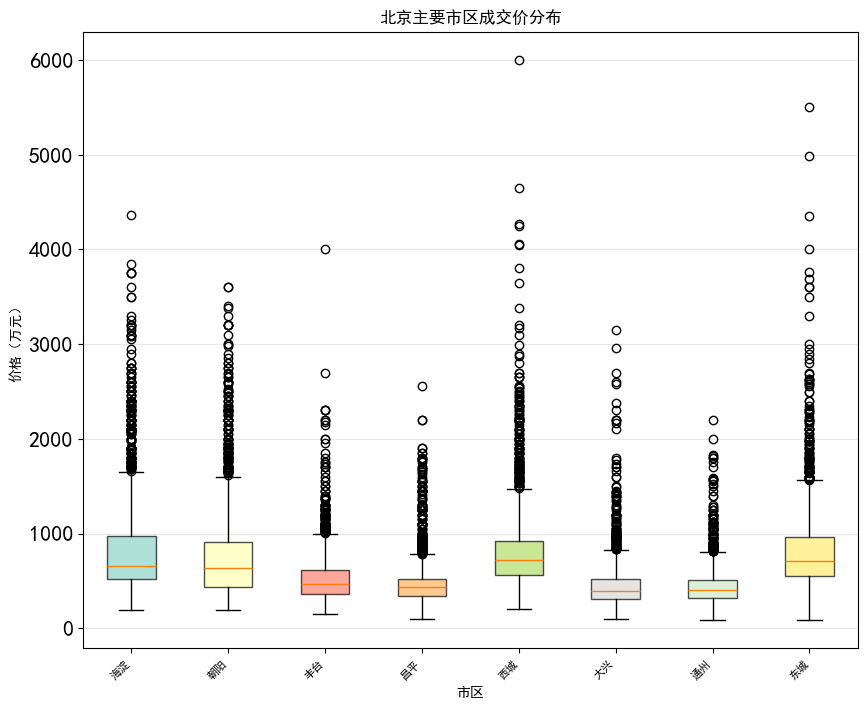

In [110]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文
plt.rcParams['axes.unicode_minus'] = False    # 显示负号
# 不同区域成交单价分布箱线图
plt.figure(figsize=(10, 8))
# 选择成交数量前8的区域
top_areas = df['市区'].value_counts().head(8).index
area_data = [df[df['市区'] == area]['价格(万元)'].values for area in top_areas]

# 绘制箱线图
box_plot = plt.boxplot(area_data, labels=top_areas, patch_artist=True)
# 设置箱体颜色
colors = plt.cm.Set3(np.linspace(0, 1, len(top_areas)))
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('北京主要市区成交价分布', fontsize=12, fontweight='bold')
plt.xlabel('市区', fontsize=10)
plt.ylabel('价格（万元）', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(True, alpha=0.3, axis='y')

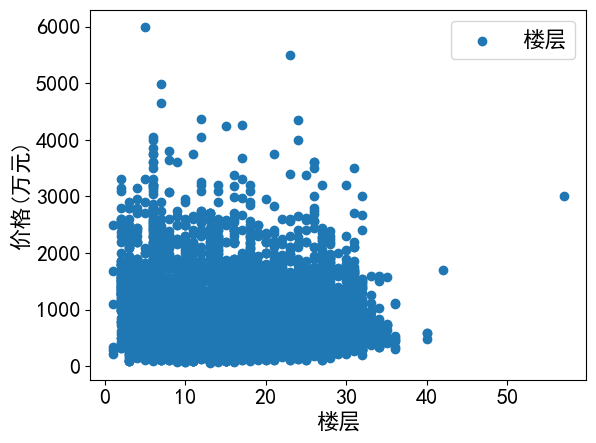

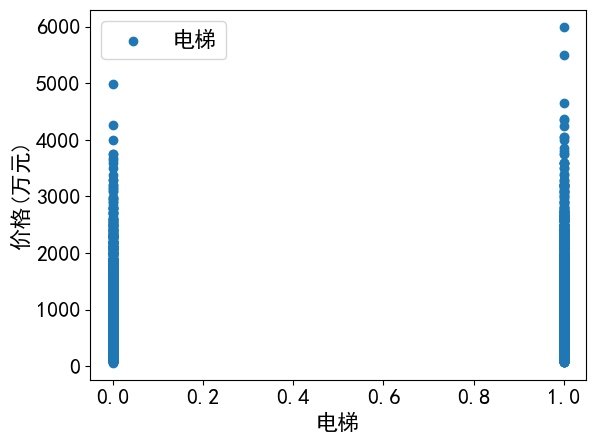

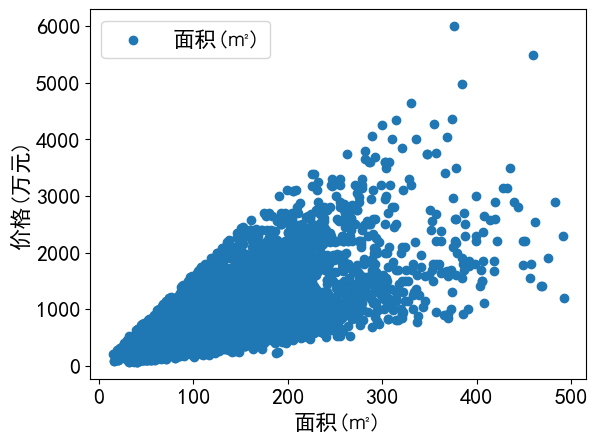

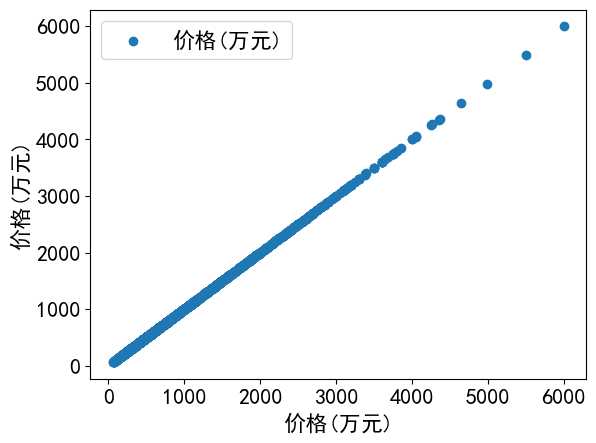

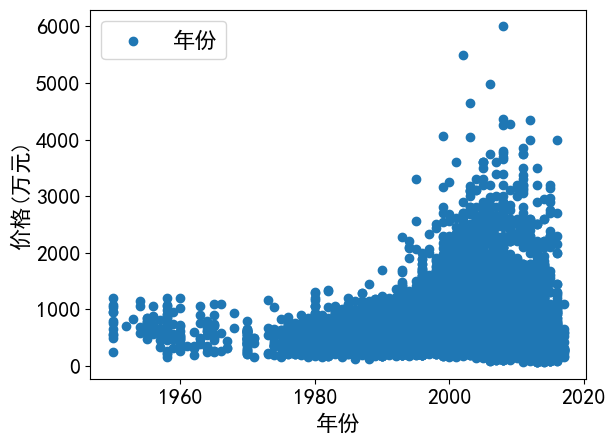

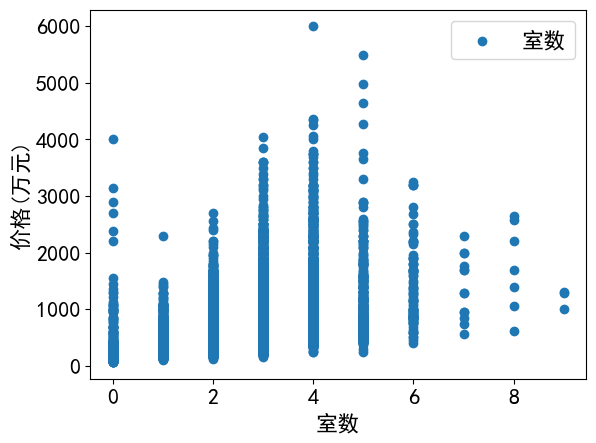

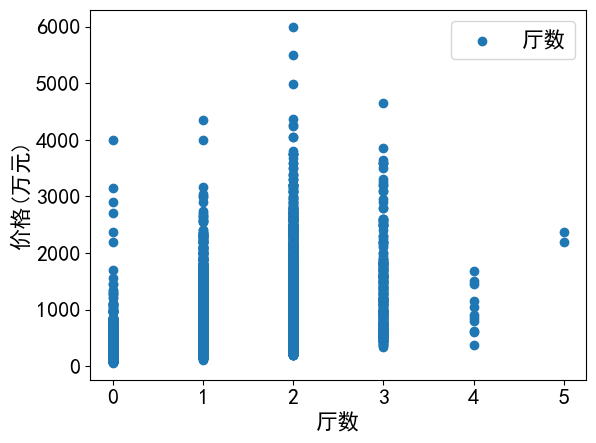

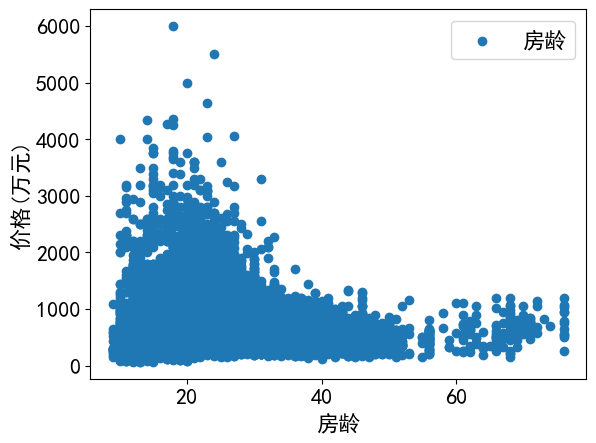

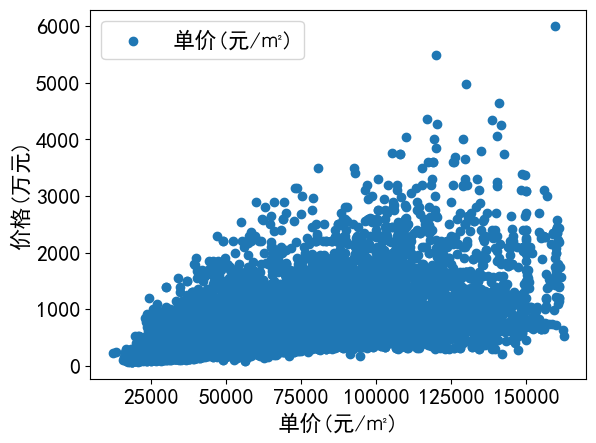

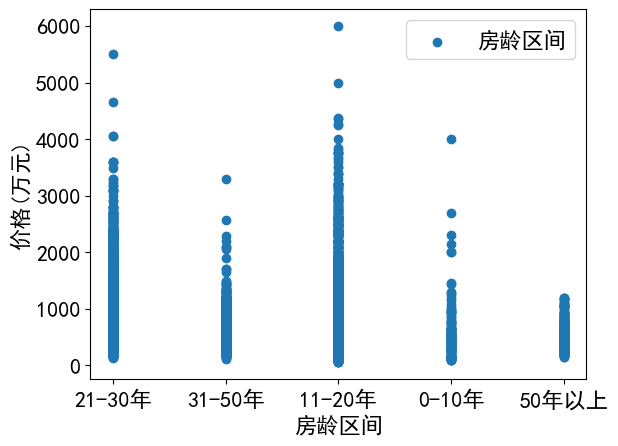

In [111]:
for j in columns_numerical:
    plt.scatter(df[j],df['价格(万元)'],label=j)
    plt.xlabel(j)
    plt.ylabel('价格(万元)')
    plt.legend()
    plt.show()

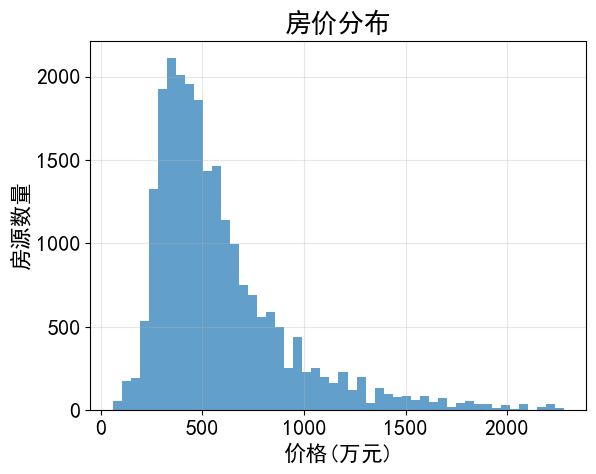

In [112]:
### 价格分布
price_99 = df['价格(万元)'].quantile(0.99)
plt.hist(df[df['价格(万元)'] <= price_99]['价格(万元)'] , bins = 50,color='#1f77b4', alpha=0.7)

plt.title('房价分布', fontweight='bold')
plt.xlabel('价格(万元)')
plt.ylabel('房源数量')
plt.grid(alpha=0.3)
plt.show()

## 上海二手房数据预处理 （穆奕）

In [113]:
data = pd.read_excel('shanghaifangjia.xlsx')
data = data.drop(columns = ['城市','网页链接'])
data

,成交日期,区域,商圈,小区,户型,朝向,楼层,面积（m²）,挂牌价（万元）,成交价（万元）,成交单价（元）,成交周期
0,2025.08.02,浦东,洋泾,中星恬园,2室2厅,南 北,高楼层 共8层,103.21,960.0,900.0,87201,11天
1,2025.08.02,闵行,金汇,锦绣江南(四期),3室2厅,南 北,中楼层 共12层,131.37,999.0,948.0,72163,124天
2,2025.08.02,长宁,古北,美丽华花园(公寓),3室2厅,东南,中楼层 共17层,156.97,1090.0,960.0,61158,238天
3,2025.08.02,黄浦,打浦桥,海悦花园,3室2厅,西南,低楼层 共26层,119.60,1073.0,1030.0,86120,52天
4,2025.08.02,静安,江宁路,静安晶华园,2室2厅,南,高楼层 共33层,111.55,1270.0,1164.0,104348,273天
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025.05.23,浦东,高行,凯鑫苑,2室1厅,南,中楼层 共4层,97.58,650.0,568.0,58209,62天
9996,2025.05.23,黄浦,蓬莱公园,制造局后街24-28号,1室1厅,南,中楼层 共7层,37.39,338.0,307.2,82162,87天
9997,2025.05.23,浦东,世博,昌四小区,2室1厅,南,高楼层 共6层,57.68,270.0,240.0,41609,7天
9998,2025.05.23,杨浦,中原,市光二村,2室1厅,东南,中楼层 共18层,71.66,299.0,275.0,38376,176天


In [114]:
print(f"数据形状: {data.shape} ")
print(f"\n数据类型:")
print(data.dtypes)
data


数据形状: (10000, 12) 

数据类型:
成交日期        object
区域          object
商圈          object
小区          object
户型          object
朝向          object
楼层          object
面积（m²）     float64
挂牌价（万元）    float64
成交价（万元）    float64
成交单价（元）      int64
成交周期        object
dtype: object


,成交日期,区域,商圈,小区,户型,朝向,楼层,面积（m²）,挂牌价（万元）,成交价（万元）,成交单价（元）,成交周期
0,2025.08.02,浦东,洋泾,中星恬园,2室2厅,南 北,高楼层 共8层,103.21,960.0,900.0,87201,11天
1,2025.08.02,闵行,金汇,锦绣江南(四期),3室2厅,南 北,中楼层 共12层,131.37,999.0,948.0,72163,124天
2,2025.08.02,长宁,古北,美丽华花园(公寓),3室2厅,东南,中楼层 共17层,156.97,1090.0,960.0,61158,238天
3,2025.08.02,黄浦,打浦桥,海悦花园,3室2厅,西南,低楼层 共26层,119.60,1073.0,1030.0,86120,52天
4,2025.08.02,静安,江宁路,静安晶华园,2室2厅,南,高楼层 共33层,111.55,1270.0,1164.0,104348,273天
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025.05.23,浦东,高行,凯鑫苑,2室1厅,南,中楼层 共4层,97.58,650.0,568.0,58209,62天
9996,2025.05.23,黄浦,蓬莱公园,制造局后街24-28号,1室1厅,南,中楼层 共7层,37.39,338.0,307.2,82162,87天
9997,2025.05.23,浦东,世博,昌四小区,2室1厅,南,高楼层 共6层,57.68,270.0,240.0,41609,7天
9998,2025.05.23,杨浦,中原,市光二村,2室1厅,东南,中楼层 共18层,71.66,299.0,275.0,38376,176天


In [115]:
duplicate_count = data.duplicated().sum()
print(f"完全重复的行数: {duplicate_count}")

完全重复的行数: 3


In [116]:
data = data.drop_duplicates()
print(f"去重后数据行数: {len(data)} 行")
print(f"成功移除: {duplicate_count} 行重复数据")

去重后数据行数: 9997 行
成功移除: 3 行重复数据


In [117]:
#去除异常值
Q1 = data['面积（m²）'].quantile(0.25)
Q3 = data['面积（m²）'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['面积（m²）'] >= lower_bound) & (data['面积（m²）'] <= upper_bound)]

# 移除包含 '-' 的行
contains_dash = data.astype(str).apply(lambda x: x.str.contains('-', na=False)).any(axis=1)
dash_rows_count = contains_dash.sum()
data= data[~contains_dash]
print(f"去掉异常值后数据行数: {len(data)} 行")

去掉异常值后数据行数: 9148 行


In [118]:
#处理楼层信息
def extract_floor_info(floor_str):
    floor_type_match = re.search(r'(高楼层|中楼层|低楼层)', floor_str)
    floor_type = floor_type_match.group(1) if floor_type_match else '未知'
    total_floor_match = re.search(r'共(\d+)层', floor_str)
    total_floors = int(total_floor_match.group(1)) if total_floor_match else np.nan
    return floor_type, total_floors

floor_info = data['楼层'].apply(extract_floor_info)
data['楼层类型'] = [x[0] for x in floor_info]
data['总层数'] = [x[1] for x in floor_info]

#  处理成交周期
def extract_days(cycle_str):
    day_match = re.search(r'(\d+)天', cycle_str)
    return int(day_match.group(1)) if day_match else np.nan

data['成交周期（天）'] = data['成交周期'].str.replace('天', '', regex=False)

#  处理户型信息

def extract_house_type(house_type_str):
    """
    从户型字符串中提取卧室和客厅数量
    例如：'3室2厅' -> (3, 2)
         '1室1厅' -> (1, 1)
         '2室' -> (2, 0)  # 如果没有厅，设为0
    """
    if pd.isna(house_type_str):  # 处理空值
        return np.nan, np.nan
    
    house_type_str = str(house_type_str)  # 确保是字符串
    
    # 提取卧室数量
    room_match = re.search(r'(\d+)室', house_type_str)
    rooms = int(room_match.group(1)) if room_match else np.nan
    
    # 提取客厅数量
    hall_match = re.search(r'(\d+)厅', house_type_str)
    halls = int(hall_match.group(1)) if hall_match else np.nan
    
    return rooms, halls

house_info = data['户型'].apply(extract_house_type)
data['卧室数量'] = [x[0] for x in house_info]
data['客厅数量'] = [x[1] for x in house_info]


## 处理房屋朝向数据
print(data['朝向'].value_counts().head(10))
def standardize_orientation(orient):
    # 处理缺失值/空值
    if pd.isna(orient) or orient == '':
        return '未知'
    if '南北' in orient or '北南' in orient:
        return '南北'
    elif '东南' in orient or '南东' in orient:
        return '东南'
    elif '西南' in orient or '南西' in orient:
        return '西南'
    elif '东北' in orient or '北东' in orient:
        return '东北'
    elif '西北' in orient or '北西' in orient:
        return '西北'
    elif '南' in orient:
        return '南'
    elif '北' in orient:
        return '北'
    elif '东' in orient:
        return '东'
    elif '西' in orient:
        return '西'
    else:
        return '其他' 
data['朝向'] = data['朝向'].apply(standardize_orientation)
print("\n清洗后朝向分布：")
print(data['朝向'].value_counts())

朝向
南       6285
南 北     2178
东南       107
西南        91
北         79
东         77
东 南       37
西         35
北 南       34
东南 南      23
Name: count, dtype: int64

清洗后朝向分布：
朝向
南     8605
东南     152
西南     136
东       91
北       89
西       35
西北      21
东北      19
Name: count, dtype: int64


## 上海二手房基础数据可视化  （穆奕）

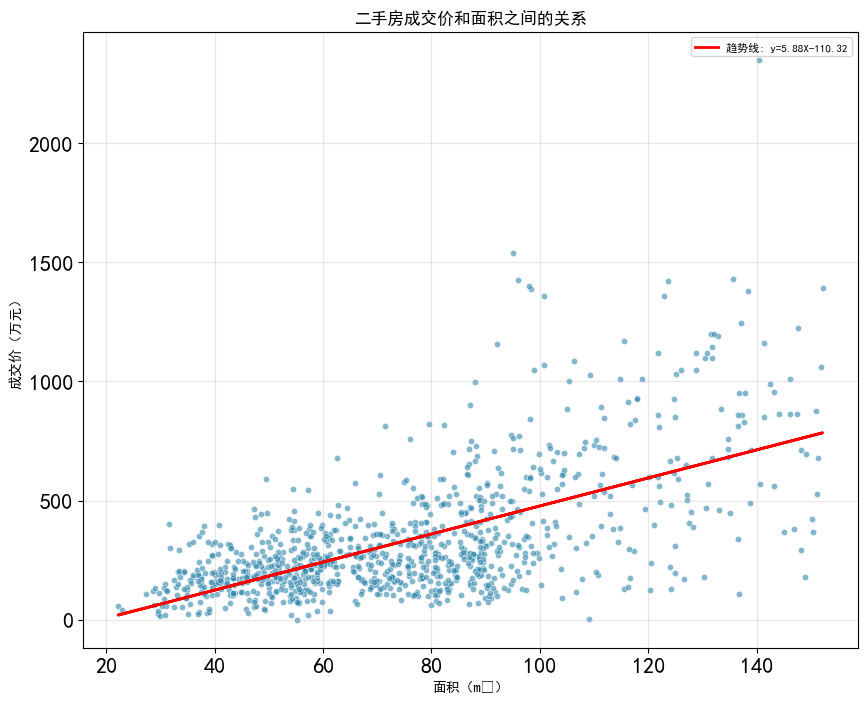

In [119]:
plt.figure(figsize=(10, 8))

# 采样1000个点避免图表过于密集
sample_df = data.sample(n=min(1000, len(df)), random_state=42)
plt.scatter(sample_df['面积（m²）'], sample_df['成交价（万元）'], 
            alpha=0.6, s=20, c='#2E86AB', edgecolors='white', linewidth=0.5)

# 添加趋势线
z = np.polyfit(sample_df['面积（m²）'], sample_df['成交价（万元）'], 1)
p = np.poly1d(z)
plt.plot(sample_df['面积（m²）'], p(sample_df['面积（m²）']), 
         color='r', linewidth=2, label=f'趋势线: y={z[0]:.2f}X{z[1]:.2f}')
plt.title('二手房成交价和面积之间的关系', fontsize=12, fontweight='bold')
plt.xlabel('面积（m²）', fontsize=10)
plt.ylabel('成交价（万元）', fontsize=10)
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

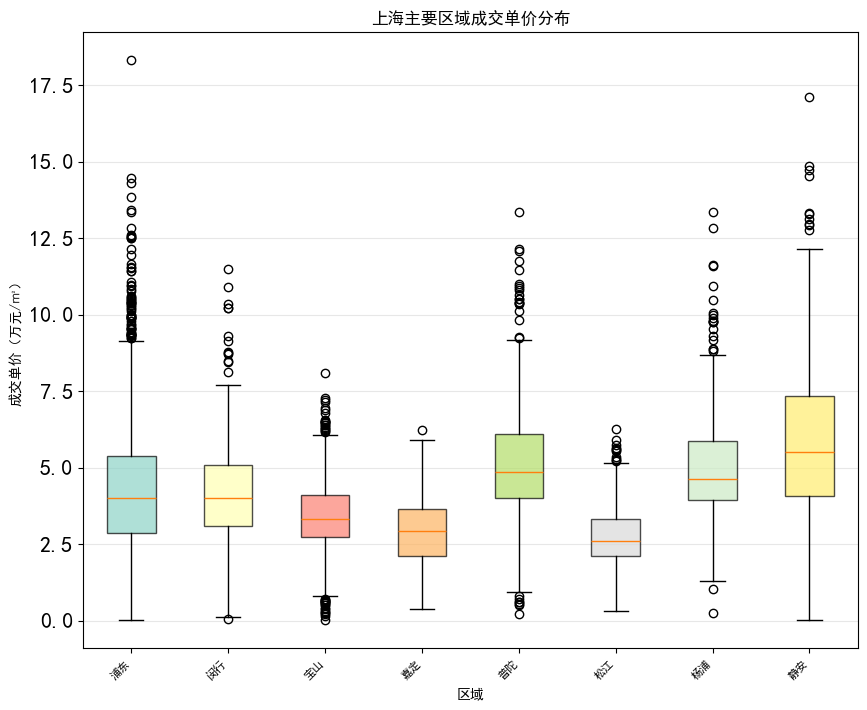

In [120]:
# 不同区域成交单价分布箱线图
plt.figure(figsize=(10, 8))
# 选择成交数量前8的区域
top_areas = data['区域'].value_counts().head(8).index
area_data = [data[data['区域'] == area]['成交单价（元）']/10000 for area in top_areas]

# 绘制箱线图
box_plot = plt.boxplot(area_data, labels=top_areas, patch_artist=True)
# 设置箱体颜色
colors = plt.cm.Set3(np.linspace(0, 1, len(top_areas)))
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('上海主要区域成交单价分布', fontsize=12, fontweight='bold')
plt.xlabel('区域', fontsize=10)
plt.ylabel('成交单价（万元/㎡）', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(True, alpha=0.3, axis='y')

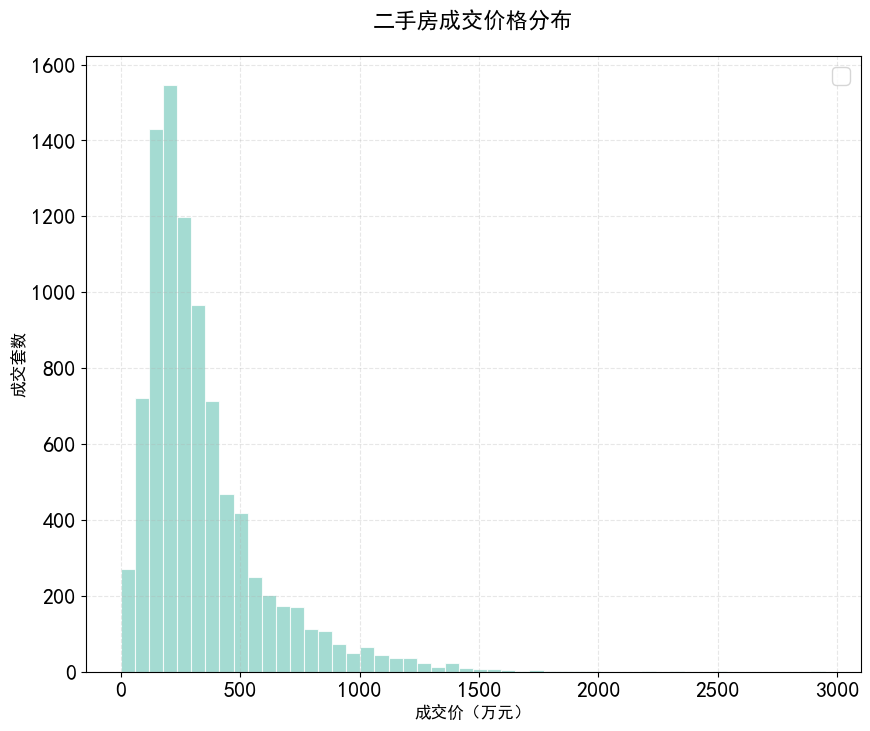

In [121]:
## 二手房价格分布

plt.figure(figsize=(10, 8))
price_data = data['成交价（万元）']
n, bins, patches = plt.hist(price_data, bins=50, alpha=0.8, color=colors[0], edgecolor='white', linewidth=0.8)

mean_price = price_data.mean()
median_price = price_data.median()


plt.title('二手房成交价格分布', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('成交价（万元）', fontsize=12)
plt.ylabel('成交套数', fontsize=12)
plt.legend()
plt.grid(alpha=0.3, linestyle='--')

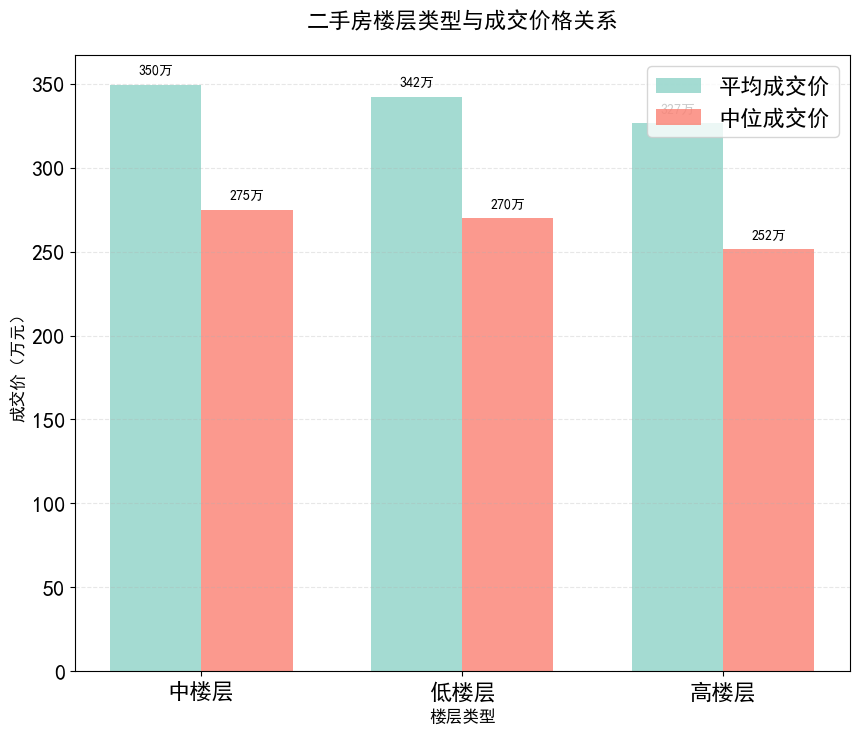

In [122]:
## 不同楼层类型的房屋成交价格
plt.figure(figsize=(10, 8))

floor_price = data.groupby('楼层类型')['成交价（万元）'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

# 只显示有效楼层类型
floor_price = floor_price[floor_price['count'] >= 100]
x_pos = np.arange(len(floor_price))

# 双柱状图
width = 0.35
bars1 = plt.bar(x_pos - width/2, floor_price['mean'], width, label='平均成交价', color=colors[0], alpha=0.8)
bars2 = plt.bar(x_pos + width/2, floor_price['median'], width, label='中位成交价', color=colors[2], alpha=0.8)

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5, f'{height:.0f}万', ha='center', va='bottom', fontsize=10)

plt.title('二手房楼层类型与成交价格关系', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('楼层类型', fontsize=12)
plt.ylabel('成交价（万元）', fontsize=12)
plt.xticks(ticks=x_pos,labels=floor_price.index, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3, linestyle='--', axis='y')
plt.show()

In [123]:
data

,成交日期,区域,商圈,小区,户型,朝向,楼层,面积（m²）,挂牌价（万元）,成交价（万元）,成交单价（元）,成交周期,楼层类型,总层数,成交周期（天）,卧室数量,客厅数量
0,2025.08.02,浦东,洋泾,中星恬园,2室2厅,南,高楼层 共8层,103.21,960.0,900.0,87201,11天,高楼层,8,11,2.0,2.0
1,2025.08.02,闵行,金汇,锦绣江南(四期),3室2厅,南,中楼层 共12层,131.37,999.0,948.0,72163,124天,中楼层,12,124,3.0,2.0
3,2025.08.02,黄浦,打浦桥,海悦花园,3室2厅,西南,低楼层 共26层,119.60,1073.0,1030.0,86120,52天,低楼层,26,52,3.0,2.0
4,2025.08.02,静安,江宁路,静安晶华园,2室2厅,南,高楼层 共33层,111.55,1270.0,1164.0,104348,273天,高楼层,33,273,2.0,2.0
6,2025.08.02,浦东,碧云,金桥爱建园,3室2厅,南,中楼层 共11层,142.22,1350.0,1312.0,92251,22天,中楼层,11,22,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,2025.05.23,闵行,莘庄南广场,金都花好悦园,3室2厅,南,中楼层 共6层,126.00,650.0,629.0,49921,5天,中楼层,6,5,3.0,2.0
9995,2025.05.23,浦东,高行,凯鑫苑,2室1厅,南,中楼层 共4层,97.58,650.0,568.0,58209,62天,中楼层,4,62,2.0,1.0
9997,2025.05.23,浦东,世博,昌四小区,2室1厅,南,高楼层 共6层,57.68,270.0,240.0,41609,7天,高楼层,6,7,2.0,1.0
9998,2025.05.23,杨浦,中原,市光二村,2室1厅,东南,中楼层 共18层,71.66,299.0,275.0,38376,176天,中楼层,18,176,2.0,1.0


# 机器学习

## 上海房价数据机器学习算法预测 （张楚仪）

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [125]:
data

,成交日期,区域,商圈,小区,户型,朝向,楼层,面积（m²）,挂牌价（万元）,成交价（万元）,成交单价（元）,成交周期,楼层类型,总层数,成交周期（天）,卧室数量,客厅数量
0,2025.08.02,浦东,洋泾,中星恬园,2室2厅,南,高楼层 共8层,103.21,960.0,900.0,87201,11天,高楼层,8,11,2.0,2.0
1,2025.08.02,闵行,金汇,锦绣江南(四期),3室2厅,南,中楼层 共12层,131.37,999.0,948.0,72163,124天,中楼层,12,124,3.0,2.0
3,2025.08.02,黄浦,打浦桥,海悦花园,3室2厅,西南,低楼层 共26层,119.60,1073.0,1030.0,86120,52天,低楼层,26,52,3.0,2.0
4,2025.08.02,静安,江宁路,静安晶华园,2室2厅,南,高楼层 共33层,111.55,1270.0,1164.0,104348,273天,高楼层,33,273,2.0,2.0
6,2025.08.02,浦东,碧云,金桥爱建园,3室2厅,南,中楼层 共11层,142.22,1350.0,1312.0,92251,22天,中楼层,11,22,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,2025.05.23,闵行,莘庄南广场,金都花好悦园,3室2厅,南,中楼层 共6层,126.00,650.0,629.0,49921,5天,中楼层,6,5,3.0,2.0
9995,2025.05.23,浦东,高行,凯鑫苑,2室1厅,南,中楼层 共4层,97.58,650.0,568.0,58209,62天,中楼层,4,62,2.0,1.0
9997,2025.05.23,浦东,世博,昌四小区,2室1厅,南,高楼层 共6层,57.68,270.0,240.0,41609,7天,高楼层,6,7,2.0,1.0
9998,2025.05.23,杨浦,中原,市光二村,2室1厅,东南,中楼层 共18层,71.66,299.0,275.0,38376,176天,中楼层,18,176,2.0,1.0


In [126]:
#!pip install lightgbm

In [127]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import lightgbm as lgb

In [128]:
target = '成交价（万元）'
features = ['区域','商圈','小区','户型','朝向','楼层','面积（m²）']
X = data[features]
y = data[target]

# 划分训练集和测试集（7:3）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 特征预处理管道（区分数值型/类别型特征）
numeric_features = [ '面积（m²）']
categorical_features = ['区域', '商圈', '小区', '户型','朝向','楼层']
# 数值特征处理：缺失值填充+标准化
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 类别特征处理：缺失值填充+One-Hot编码
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 合并预处理步骤
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

多模型房价预测效果评估

【线性回归】
平均绝对误差(MAE)：75.22 万元
均方根误差(RMSE)：133.56 万元
决定系数(R²)：0.7335

【随机森林】
平均绝对误差(MAE)：70.62 万元
均方根误差(RMSE)：126.17 万元
决定系数(R²)：0.7622

【LightGBM】
平均绝对误差(MAE)：74.55 万元
均方根误差(RMSE)：127.36 万元
决定系数(R²)：0.7577


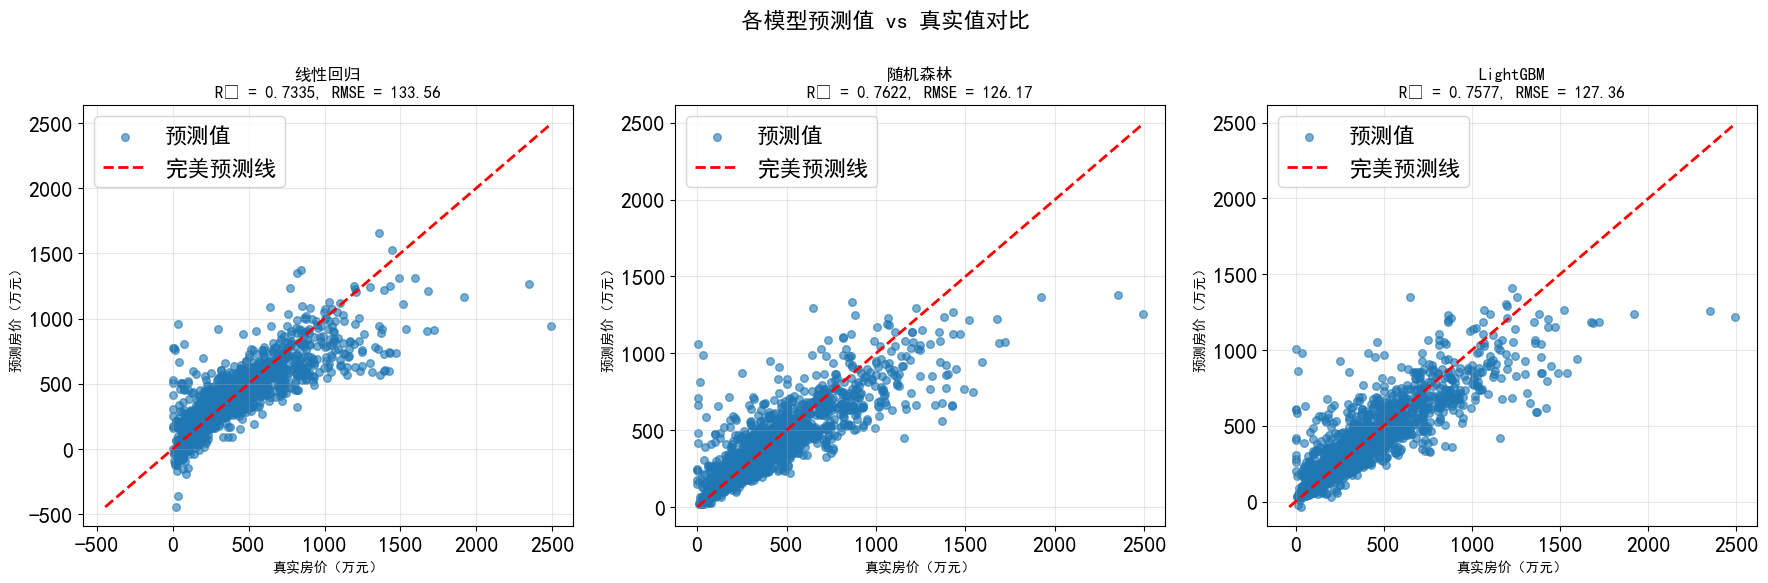

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import lightgbm as lgb

# 设置中文字体（解决中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 假设你已经定义了 preprocessor、X_train、X_test、y_train、y_test
# 这里是你的原始代码
models = {
    '线性回归': LinearRegression(),
    '随机森林': RandomForestRegressor(n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
}

# 训练并评估每个模型
results = {}
print("="*80)
print("多模型房价预测效果评估")
print("="*80)

# 创建画布，设置子图布局（1行3列）
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('各模型预测值 vs 真实值对比', fontsize=16, fontweight='bold')

# 用于遍历子图的索引
ax_idx = 0

for name, model in models.items():
    # 构建完整管道（预处理+模型）
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # 训练模型
    pipeline.fit(X_train, y_train)
    
    # 预测
    y_pred = pipeline.predict(X_test)
    
    # 计算评估指标
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # 保存结果
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': pipeline,  # 保存训练好的模型
        'y_pred': y_pred    # 保存预测值，方便后续使用
    }
    
    # 输出结果
    print(f"\n【{name}】")
    print(f"平均绝对误差(MAE)：{mae:.2f} 万元")
    print(f"均方根误差(RMSE)：{rmse:.2f} 万元")
    print(f"决定系数(R²)：{r2:.4f}")
    
    # 绘制预测值vs真实值对比图
    ax = axes[ax_idx]
    
    # 绘制散点图
    ax.scatter(y_test, y_pred, alpha=0.6, s=30, label='预测值')
    
    # 绘制完美预测线（y=x）
    min_val = min(min(y_test), min(y_pred))
    max_val = max(max(y_test), max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='完美预测线')
    
    # 设置标题和标签
    ax.set_title(f'{name}\nR² = {r2:.4f}, RMSE = {rmse:.2f}', fontsize=12)
    ax.set_xlabel('真实房价（万元）', fontsize=10)
    ax.set_ylabel('预测房价（万元）', fontsize=10)
    
    # 添加网格和图例
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # 索引+1
    ax_idx += 1

# 调整子图间距
plt.tight_layout()
plt.savefig('房价预测模型对比图.png', dpi=300, bbox_inches='tight')
# 显示图片
plt.show()

### 模型对比评估与分析（余菲菲）


模型评估指标汇总
         模型  MAE(万元)  RMSE(万元)      R²
0      线性回归  75.2246  133.5627  0.7335
1      随机森林  70.6183  126.1679  0.7622
2  LightGBM  74.5537  127.3631  0.7577


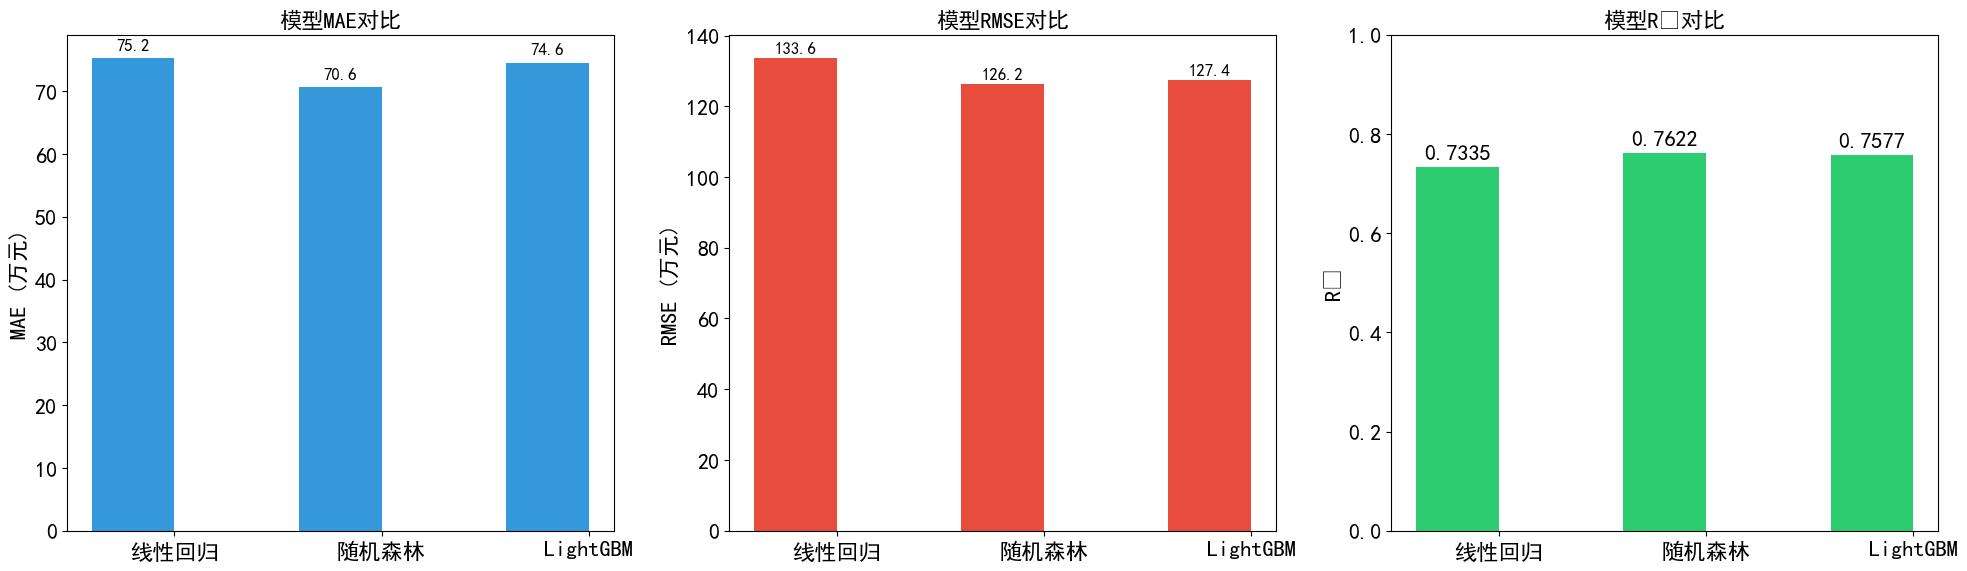

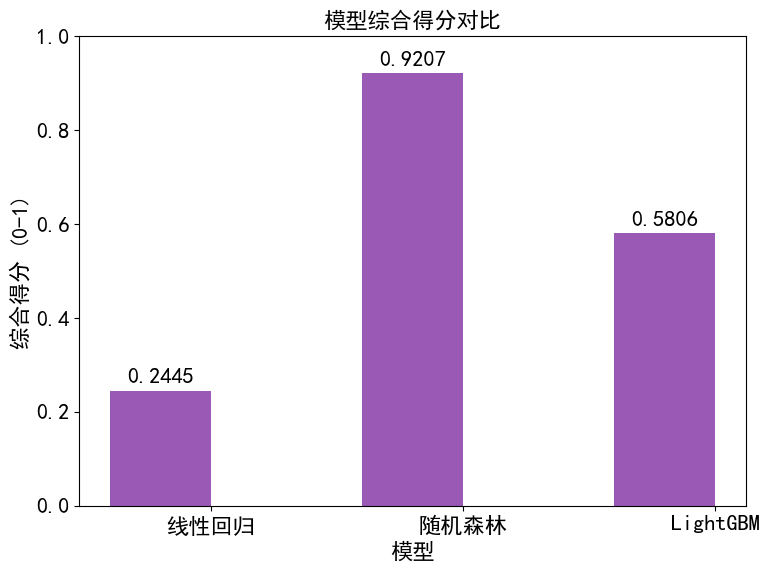

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # 提前导入避免Q-Q图报错
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 统一调整全局字体大小基准（核心改动）
plt.rcParams['font.size'] = 16  # 全局默认字号从10改为16
# 注意：需确保运行前已定义results变量，否则注释掉下面这行或替换为实际的结果字典
shanghai_result = results  

# 1. 整理评估指标结果
metrics_df = pd.DataFrame({
    '模型': list(shanghai_result.keys()),
    'MAE(万元)': [shanghai_result[model]['MAE'] for model in shanghai_result.keys()],
    'RMSE(万元)': [shanghai_result[model]['RMSE'] for model in shanghai_result.keys()],
    'R²': [shanghai_result[model]['R²'] for model in shanghai_result.keys()]
})

print("\n" + "="*60)
print("模型评估指标汇总")
print("="*60)
print(metrics_df.round(4))

# 2. 可视化模型评估指标对比
fig, axes = plt.subplots(1, 3, figsize=(20, 6))  # 1行3列，调整画布尺寸适配

# 2.1 MAE对比（第一个子图）
ax1 = axes[0]
x_pos = np.arange(len(metrics_df['模型']))
bars1 = ax1.bar(x_pos - 0.2, metrics_df['MAE(万元)'], 0.4, label='MAE', color='#3498db')
ax1.set_title('模型MAE对比', fontsize=16, fontweight='bold')
#ax1.set_xlabel('模型', fontsize=16)  # X轴标签14号字
ax1.set_ylabel('MAE (万元)', fontsize=16)  # Y轴标签14号字
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics_df['模型'], fontsize=16)
# 在柱子上添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=12)

# 2.2 RMSE对比（第二个子图）
ax2 = axes[1]
bars2 = ax2.bar(x_pos - 0.2, metrics_df['RMSE(万元)'], 0.4, label='RMSE', color='#e74c3c')
ax2.set_title('模型RMSE对比', fontsize=16, fontweight='bold')
#ax2.set_xlabel('模型', fontsize=16)  # X轴标签14号字
ax2.set_ylabel('RMSE (万元)', fontsize=16)  # Y轴标签14号字
ax2.set_xticks(x_pos)
ax2.set_xticklabels(metrics_df['模型'], fontsize=16)
# 在柱子上添加数值标签
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=12)

# 2.3 R²对比（第三个子图）
ax3 = axes[2]
bars3 = ax3.bar(x_pos - 0.2, metrics_df['R²'], 0.4, label='R²', color='#2ecc71')
ax3.set_title('模型R²对比', fontsize=16, fontweight='bold')
#ax3.set_xlabel('模型', fontsize=16)  # X轴标签14号字
ax3.set_ylabel('R²', fontsize=16)  # Y轴标签14号字
ax3.set_xticks(x_pos)
ax3.set_xticklabels(metrics_df['模型'], fontsize=16)
ax3.set_ylim(0, 1)  # R²范围0-1
# 在柱子上添加数值标签
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=16)

# 调整前3个子图的布局间距
plt.tight_layout()
#plt.savefig('模型MAE_RMSE_R2对比.png', dpi=300, bbox_inches='tight')
plt.show()

# 2.4 综合指标对比（归一化）- 单独绘制
fig, ax4 = plt.subplots(1, 1, figsize=(8, 6))  # 单独画布
# 归一化处理（MAE和RMSE越小越好，R²越大越好）
metrics_df['MAE_norm'] = 1 - (metrics_df['MAE(万元)'] - metrics_df['MAE(万元)'].min()) / (metrics_df['MAE(万元)'].max() - metrics_df['MAE(万元)'].min())
metrics_df['RMSE_norm'] = 1 - (metrics_df['RMSE(万元)'] - metrics_df['RMSE(万元)'].min()) / (metrics_df['RMSE(万元)'].max() - metrics_df['RMSE(万元)'].min())
metrics_df['R2_norm'] = metrics_df['R²']

# 计算综合得分（平均归一化得分）
metrics_df['综合得分'] = (metrics_df['MAE_norm'] + metrics_df['RMSE_norm'] + metrics_df['R2_norm']) / 3

bars4 = ax4.bar(x_pos - 0.2, metrics_df['综合得分'], 0.4, label='综合得分', color='#9b59b6')
ax4.set_title('模型综合得分对比', fontsize=16, fontweight='bold')
ax4.set_xlabel('模型', fontsize=16)  # X轴标签14号字
ax4.set_ylabel('综合得分 (0-1)', fontsize=16)  # Y轴标签14号字
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics_df['模型'], fontsize=16)
ax4.set_ylim(0, 1)
# 在柱子上添加数值标签
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=16)

# 调整综合得分图的布局
plt.tight_layout()
plt.savefig('模型综合得分对比.png', dpi=300, bbox_inches='tight')
plt.show()


特征重要性分析（随机森林 & LightGBM）

【随机森林 - 前15个重要特征】
         特征名称     重要性
0      面积（m²）  0.4517
17      区域_黄浦  0.0337
6       区域_徐汇  0.0309
3       区域_奉贤  0.0231
16      区域_静安  0.0197
13      区域_长宁  0.0186
5       区域_崇明  0.0149
3915  户型_2室2厅  0.0123
7       区域_普陀  0.0119
2       区域_嘉定  0.0097
9       区域_松江  0.0096
171   商圈_金山新城  0.0096
8       区域_杨浦  0.0094
33     商圈_临平路  0.0081
95      商圈_惠南  0.0080


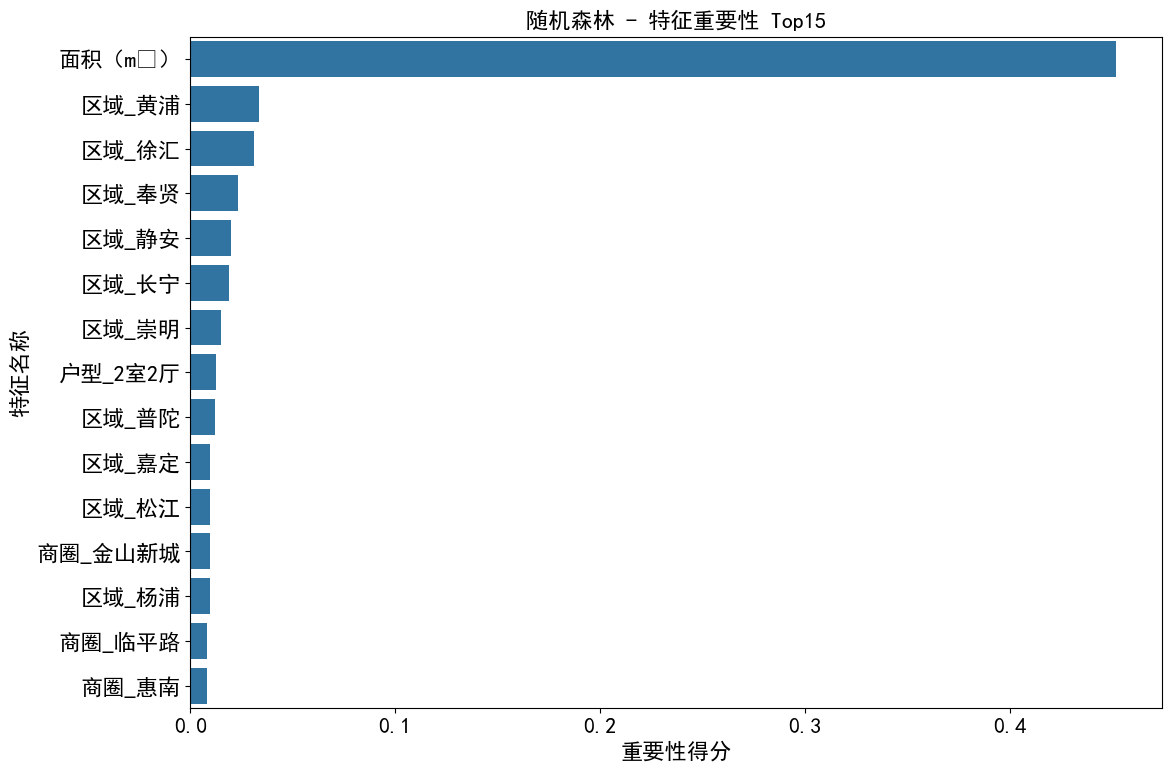


【LightGBM - 前15个重要特征】
            特征名称  重要性
0         面积（m²）  672
17         区域_黄浦   62
6          区域_徐汇   61
3          区域_奉贤   58
10         区域_浦东   56
3915     户型_2室2厅   54
3918     户型_3室2厅   52
16         区域_静安   51
12         区域_金山   48
13         区域_长宁   47
95         商圈_惠南   43
2          区域_嘉定   43
4060  楼层_高楼层 共6层   42
9          区域_松江   41
8          区域_杨浦   41


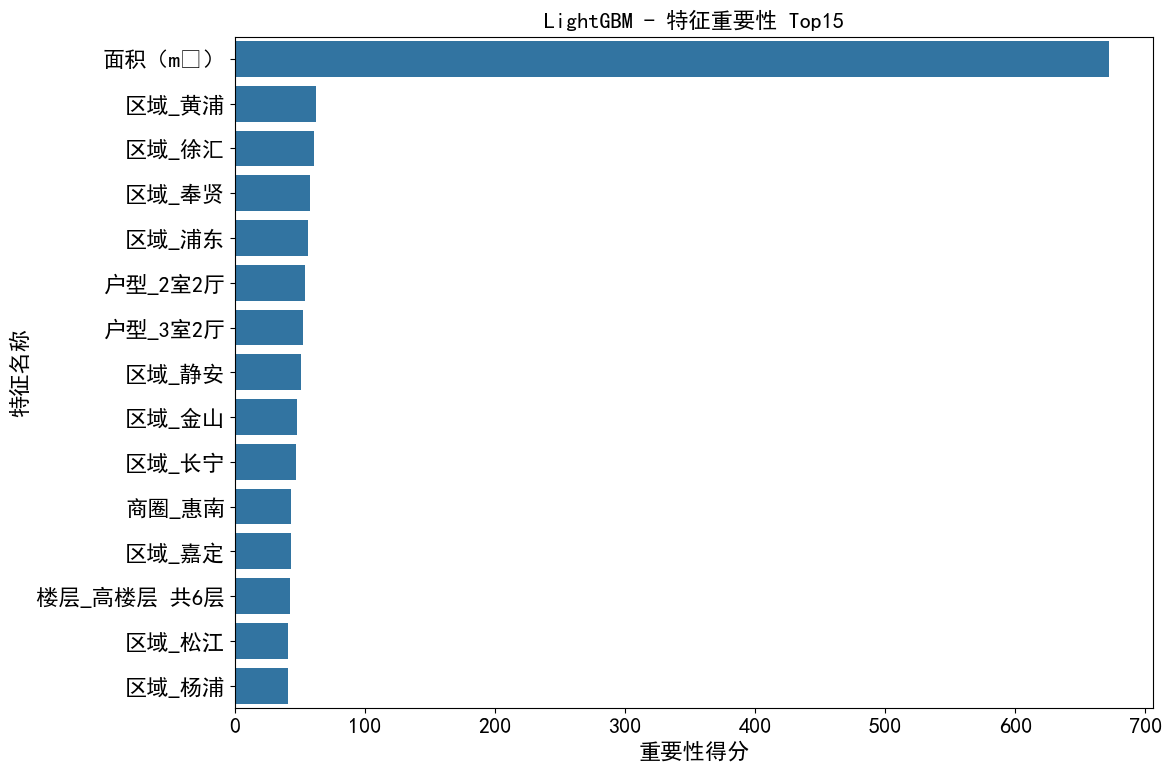


最佳模型（随机森林）预测结果分析


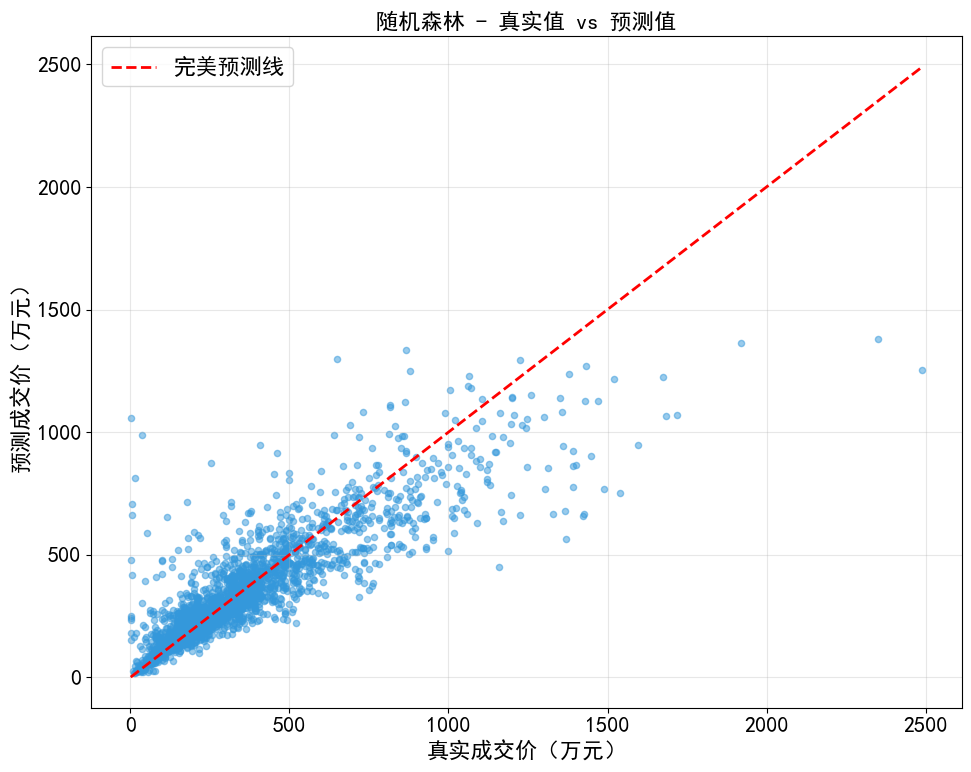

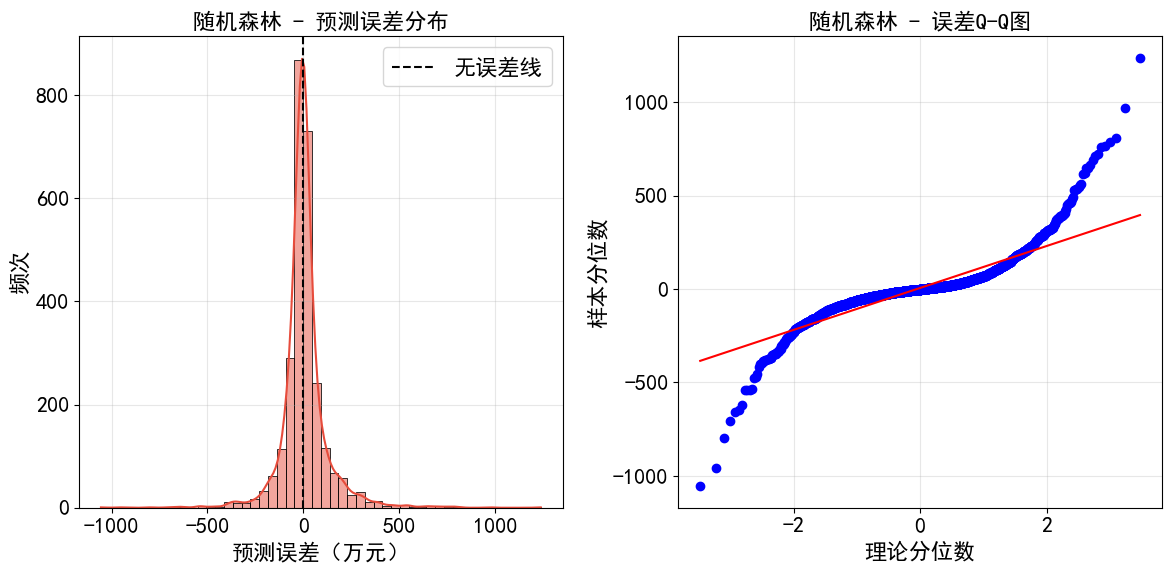


模型性能总结
1. 最佳模型：随机森林
2. 综合得分：0.9207
3. 主要优势：MAE=70.62万元，RMSE=126.17万元，R²=0.7622

4. 最佳模型误差统计：
   - 平均误差：5.67 万元
   - 误差标准差：126.06 万元
   - 最大正误差（预测偏低）：1236.87 万元
   - 最大负误差（预测偏高）：-1055.21 万元
   - 误差绝对值<50万元的样本占比：60.69%


In [133]:
# 3. 特征重要性分析（针对树模型）
print("\n" + "="*60)
print("特征重要性分析（随机森林 & LightGBM）")
print("="*60)

# 获取预处理后的特征名称
preprocessor = shanghai_result['随机森林']['model'].named_steps['preprocessor']
# 获取数值特征名称
numeric_features = ['面积（m²）']
# 获取类别特征的OneHot编码后的名称
cat_ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_ohe.get_feature_names_out(['区域', '商圈', '小区', '户型', '朝向', '楼层'])
# 合并所有特征名称
all_feature_names = list(numeric_features) + list(cat_feature_names)

# 3.1 随机森林特征重要性
rf_model = shanghai_result['随机森林']['model'].named_steps['model']
rf_importance = pd.DataFrame({
    '特征名称': all_feature_names,
    '重要性': rf_model.feature_importances_
}).sort_values('重要性', ascending=False).head(15)  # 取前15个重要特征

print("\n【随机森林 - 前15个重要特征】")
print(rf_importance.round(4))

# 可视化随机森林特征重要性
plt.figure(figsize=(12, 8))
sns.barplot(x='重要性', y='特征名称', data=rf_importance)
plt.title('随机森林 - 特征重要性 Top15', fontsize=16, fontweight='bold')
plt.xlabel('重要性得分', fontsize=16)  # X轴标签14号字
plt.ylabel('特征名称', fontsize=16)  # Y轴标签14号字
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('随机森林特征重要性.png', dpi=300, bbox_inches='tight')
plt.show()

# 3.2 LightGBM特征重要性
lgb_model = shanghai_result['LightGBM']['model'].named_steps['model']
lgb_importance = pd.DataFrame({
    '特征名称': all_feature_names,
    '重要性': lgb_model.feature_importances_
}).sort_values('重要性', ascending=False).head(15)

print("\n【LightGBM - 前15个重要特征】")
print(lgb_importance.round(4))

# 可视化LightGBM特征重要性
plt.figure(figsize=(12, 8))
sns.barplot(x='重要性', y='特征名称', data=lgb_importance)
plt.title('LightGBM - 特征重要性 Top15', fontsize=16, fontweight='bold')
plt.xlabel('重要性得分', fontsize=16)  # X轴标签14号字
plt.ylabel('特征名称', fontsize=16)  # Y轴标签14号字
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('LightGBM特征重要性.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 预测结果可视化（最佳模型：随机森林）
print("\n" + "="*60)
print("最佳模型（随机森林）预测结果分析")
print("="*60)

# 选择表现最好的模型
best_model_name = metrics_df.loc[metrics_df['综合得分'].idxmax(), '模型']
best_model = shanghai_result[best_model_name]['model']
y_pred_best = shanghai_result[best_model_name]['y_pred']

# 4.1 真实值vs预测值散点图
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='#3498db', s=20)
# 添加对角线（完美预测线）
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='完美预测线')
plt.xlabel('真实成交价（万元）', fontsize=16)  # X轴标签14号字
plt.ylabel('预测成交价（万元）', fontsize=16)  # Y轴标签14号字
plt.title(f'{best_model_name} - 真实值 vs 预测值', fontsize=16, fontweight='bold')
plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('真实值vs预测值.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.2 误差分布分析
errors = y_test - y_pred_best
plt.figure(figsize=(12, 6))

# 误差直方图
plt.subplot(1, 2, 1)
sns.histplot(errors, kde=True, bins=50, color='#e74c3c')
plt.axvline(x=0, color='black', linestyle='--', label='无误差线')
plt.xlabel('预测误差（万元）', fontsize=16)  # X轴标签14号字
plt.ylabel('频次', fontsize=16)  # Y轴标签14号字
plt.title(f'{best_model_name} - 预测误差分布', fontsize=16, fontweight='bold')
plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# 误差Q-Q图（检验正态性）
plt.subplot(1, 2, 2)
stats.probplot(errors, dist="norm", plot=plt)
plt.title(f'{best_model_name} - 误差Q-Q图', fontsize=16, fontweight='bold')
plt.xlabel('理论分位数', fontsize=16)  # 新增X轴标签，14号字
plt.ylabel('样本分位数', fontsize=16)  # 新增Y轴标签，14号字
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig('预测误差分析.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. 模型性能总结
print("\n" + "="*60)
print("模型性能总结")
print("="*60)
print(f"1. 最佳模型：{best_model_name}")
print(f"2. 综合得分：{metrics_df.loc[metrics_df['模型']==best_model_name, '综合得分'].values[0]:.4f}")
print(f"3. 主要优势：MAE={metrics_df.loc[metrics_df['模型']==best_model_name, 'MAE(万元)'].values[0]:.2f}万元，RMSE={metrics_df.loc[metrics_df['模型']==best_model_name, 'RMSE(万元)'].values[0]:.2f}万元，R²={metrics_df.loc[metrics_df['模型']==best_model_name, 'R²'].values[0]:.4f}")

# 输出误差统计
print(f"\n4. 最佳模型误差统计：")
print(f"   - 平均误差：{errors.mean():.2f} 万元")
print(f"   - 误差标准差：{errors.std():.2f} 万元")
print(f"   - 最大正误差（预测偏低）：{errors.max():.2f} 万元")
print(f"   - 最大负误差（预测偏高）：{errors.min():.2f} 万元")
print(f"   - 误差绝对值<50万元的样本占比：{(abs(errors)<50).mean()*100:.2f}%")

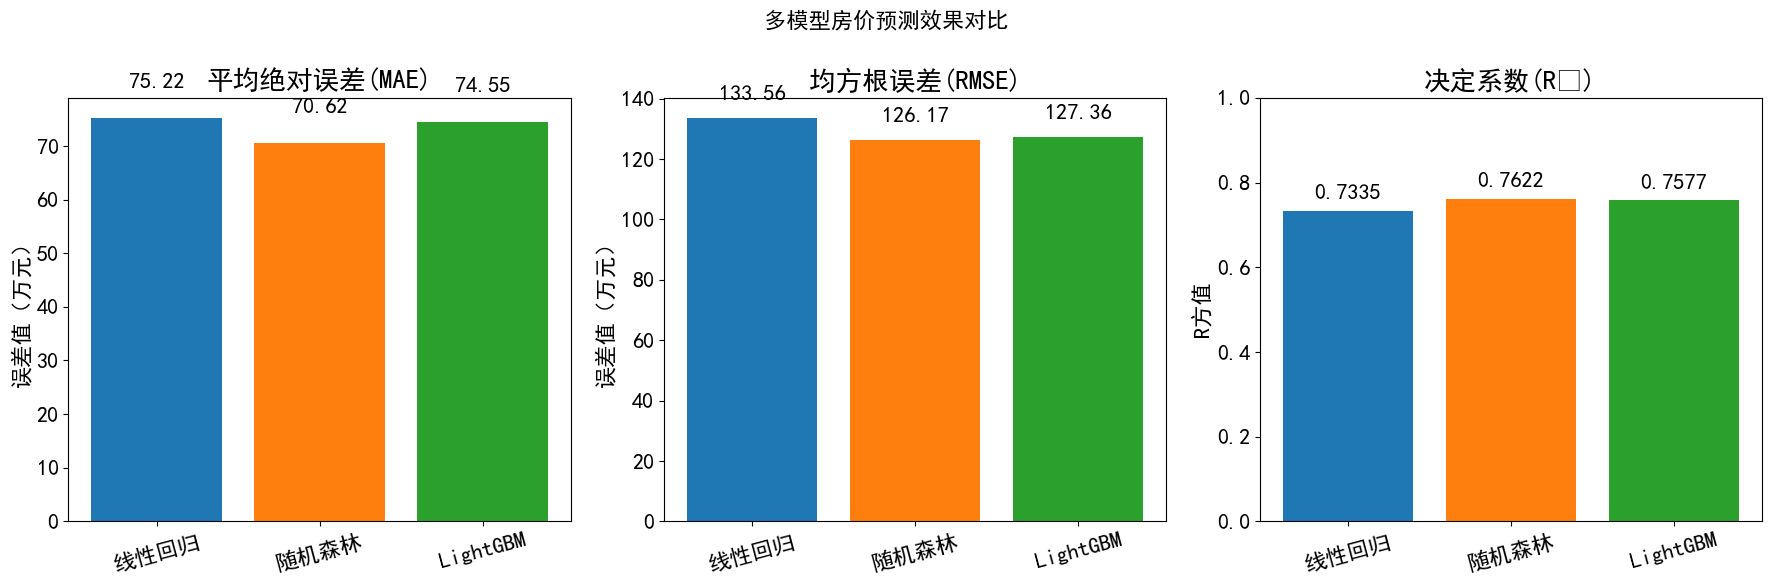

In [134]:
# 4.1 各模型评估指标对比
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('多模型房价预测效果对比', fontsize=16, fontweight='bold')

# 提取指标
model_names = list(results.keys())
mae_vals = [results[name]['MAE'] for name in model_names]
rmse_vals = [results[name]['RMSE'] for name in model_names]
r2_vals = [results[name]['R²'] for name in model_names]

# MAE对比
axes[0].bar(model_names, mae_vals, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('平均绝对误差(MAE)')
axes[0].set_ylabel('误差值（万元）')
axes[0].tick_params(axis='x', rotation=15)
# 添加数值标签
for i, v in enumerate(mae_vals):
    axes[0].text(i, v+5, f'{v:.2f}', ha='center', va='bottom')

# RMSE对比
axes[1].bar(model_names, rmse_vals, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_title('均方根误差(RMSE)')
axes[1].set_ylabel('误差值（万元）')
axes[1].tick_params(axis='x', rotation=15)
# 添加数值标签
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v+5, f'{v:.2f}', ha='center', va='bottom')

# R²对比
axes[2].bar(model_names, r2_vals, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[2].set_title('决定系数(R²)')
axes[2].set_ylabel('R方值')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=15)
# 添加数值标签
for i, v in enumerate(r2_vals):
    axes[2].text(i, v+0.02, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


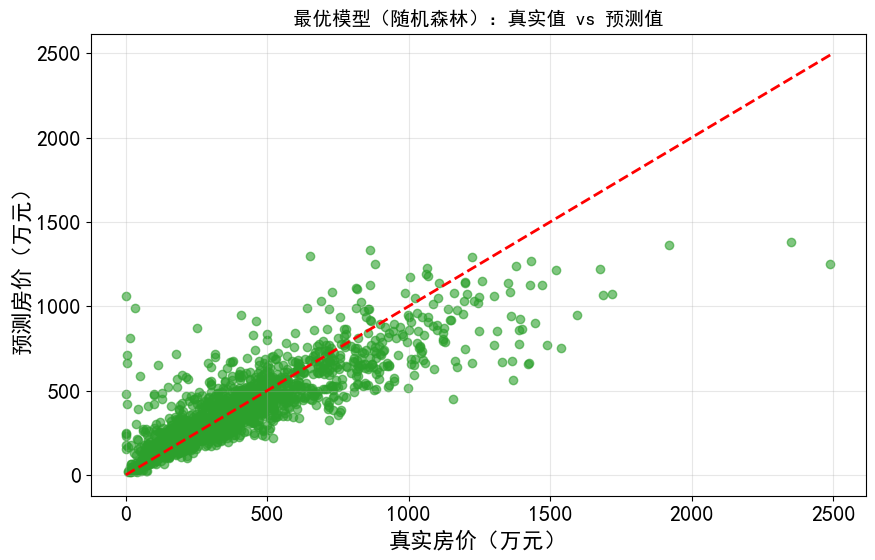

In [135]:
best_model_name = max(results.keys(), key=lambda x: results[x]['R²'])
best_model = results[best_model_name]['model']
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='#2ca02c')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('真实房价（万元）')
plt.ylabel('预测房价（万元）')
plt.title(f'最优模型（{best_model_name}）：真实值 vs 预测值', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import lightgbm as lgb

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ========== （此处省略你已有的模型训练代码，直接衔接最优模型部分） ==========

# 选择R²最高的最优模型
best_model_name = max(results.keys(), key=lambda x: results[x]['R²'])
best_model = results[best_model_name]['model']
y_pred_best = best_model.predict(X_test)

# ========== 保存真实值和预测值到CSV文件 ==========

result_df = pd.DataFrame({
    '真实房价_万元': y_test.values,  # 若y_test是Series用.values，若是数组直接用y_test
    '预测房价_万元': y_pred_best,
    '误差_万元': y_pred_best - y_test.values,  # 新增误差列，方便分析
    '绝对误差_万元': np.abs(y_pred_best - y_test.values)  # 新增绝对误差列
})

# 2. 保存到CSV文件（设置index=False避免保存行索引，encoding确保中文正常）
csv_filename = f'最优模型_{best_model_name}_预测结果.csv'
result_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
print(f"\n最优模型预测结果已保存到：{csv_filename}")

# 可选：输出CSV文件的前5行，验证数据
print("\nCSV文件前5行预览：")
print(result_df.head())


最优模型预测结果已保存到：最优模型_随机森林_预测结果.csv

CSV文件前5行预览：
   真实房价_万元     预测房价_万元      误差_万元    绝对误差_万元
0    217.0  203.985000 -13.015000  13.015000
1    237.0  265.410000  28.410000  28.410000
2    100.0  142.793000  42.793000  42.793000
3    212.0  197.229000 -14.771000  14.771000
4    275.0  277.847333   2.847333   2.847333


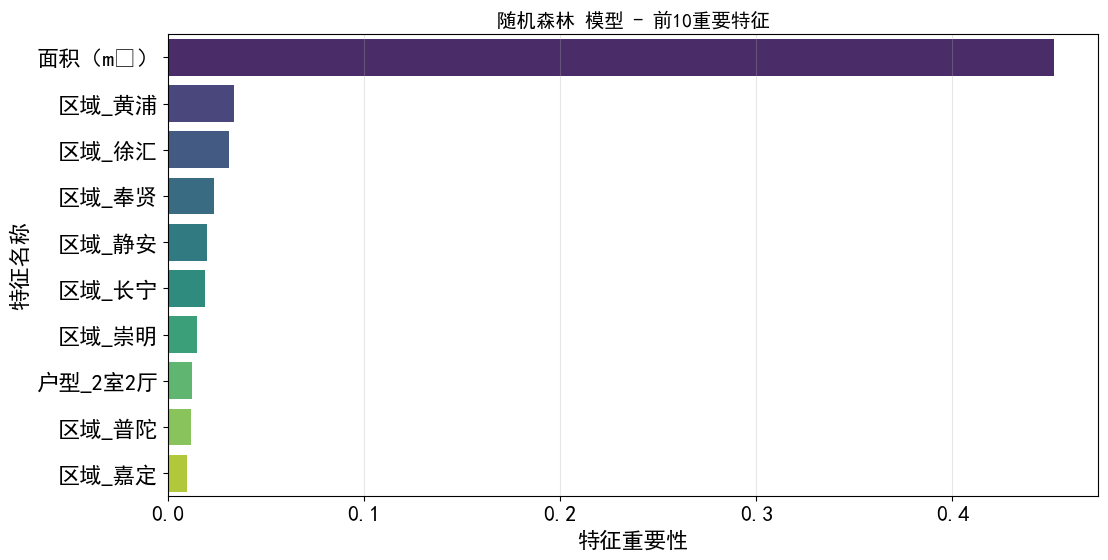


最终结论
1. 最优模型：随机森林（R²=0.7622）
2. 最差模型：线性回归（R²=0.7335）
3. 核心影响特征：面积（m²）（重要性=0.45）
4. 模型平均预测误差：70.62 万元


In [137]:
cat_features_names = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_features_names = np.concatenate([numeric_features, cat_features_names])

# 修复：分模型正确提取特征重要性
if best_model_name == '线性回归':
    # 线性回归：用系数绝对值表示重要性
    importance = np.abs(best_model.named_steps['model'].coef_)
elif best_model_name in ['随机森林', 'LightGBM']:
    # 树模型：用feature_importances_表示重要性
    importance = best_model.named_steps['model'].feature_importances_
else:
    # 兜底：默认用0填充（实际不会走到这里）
    importance = np.zeros(len(all_features_names))

# 构建特征重要性DataFrame
importance_df = pd.DataFrame({
    '特征名称': all_features_names,
    '重要性': importance
}).sort_values('重要性', ascending=False).head(10)

# 可视化特征重要性
plt.figure(figsize=(12, 6))
sns.barplot(x='重要性', y='特征名称', data=importance_df, palette='viridis')
plt.title(f'{best_model_name} 模型 - 前10重要特征', fontsize=14)
plt.xlabel('特征重要性')
plt.ylabel('特征名称')
plt.grid(True, alpha=0.3, axis='x')
plt.show()

# 输出最终结论
print("\n" + "="*80)
print("最终结论")
print("="*80)
print(f"1. 最优模型：{best_model_name}（R²={results[best_model_name]['R²']:.4f}）")
print(f"2. 最差模型：{min(results.keys(), key=lambda x: results[x]['R²'])}（R²={results[min(results.keys(), key=lambda x: results[x]['R²'])]['R²']:.4f}）")
print(f"3. 核心影响特征：{importance_df.iloc[0]['特征名称']}（重要性={importance_df.iloc[0]['重要性']:.2f}）")
print(f"4. 模型平均预测误差：{results[best_model_name]['MAE']:.2f} 万元")

## 北京房价数据机器学习算法预测 (魏灿文)

In [138]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 可视化库
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False

# 机器学习库
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 模型
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb


# 评估指标
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

### 定义特征和目标变量

In [139]:
target = '价格(万元)'
features = ['市区', '室数', '厅数', '朝向', '楼层', '装修情况', '电梯', '面积(㎡)', '房龄']
X = df[features]
y = df[target]

# 划分训练集和测试集（7:3）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 特征预处理管道（区分数值型/类别型特征）
numeric_features = ['室数', '厅数', '楼层', '面积(㎡)', '房龄']
categorical_features = ['市区', '朝向', '装修情况', '电梯']
# 数值特征处理：缺失值填充+标准化
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 类别特征处理：缺失值填充+One-Hot编码
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 合并预处理步骤
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### 多模型定义与训练 

In [140]:
models = {
    '线性回归': LinearRegression(),
    '随机森林': RandomForestRegressor(n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
}

# 训练并评估每个模型
results = {}
print("="*80)
print("多模型房价预测效果评估")
print("="*80)

for name, model in models.items():
    # 构建完整管道（预处理+模型）
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # 训练模型
    pipeline.fit(X_train, y_train)
    
    # 预测
    y_pred = pipeline.predict(X_test)
    
    # 计算评估指标
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # 保存结果
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        
        'R²': r2,
        'model': pipeline  # 保存训练好的模型
    }
    
    # 输出结果
    print(f"\n【{name}】")
    print(f"平均绝对误差(MAE)：{mae:.2f} 万元")
    print(f"均方根误差(RMSE)：{rmse:.2f} 万元")
    print(f"决定系数(R²)：{r2:.4f}")

多模型房价预测效果评估

【线性回归】
平均绝对误差(MAE)：129.78 万元
均方根误差(RMSE)：202.18 万元
决定系数(R²)：0.7416

【随机森林】
平均绝对误差(MAE)：81.95 万元
均方根误差(RMSE)：146.76 万元
决定系数(R²)：0.8639

【LightGBM】
平均绝对误差(MAE)：91.14 万元
均方根误差(RMSE)：150.91 万元
决定系数(R²)：0.8560


多模型房价预测效果评估

【线性回归】
平均绝对误差(MAE)：129.78 万元
均方根误差(RMSE)：202.18 万元
决定系数(R²)：0.7416

【随机森林】
平均绝对误差(MAE)：81.95 万元
均方根误差(RMSE)：146.76 万元
决定系数(R²)：0.8639

【LightGBM】
平均绝对误差(MAE)：91.14 万元
均方根误差(RMSE)：150.91 万元
决定系数(R²)：0.8560


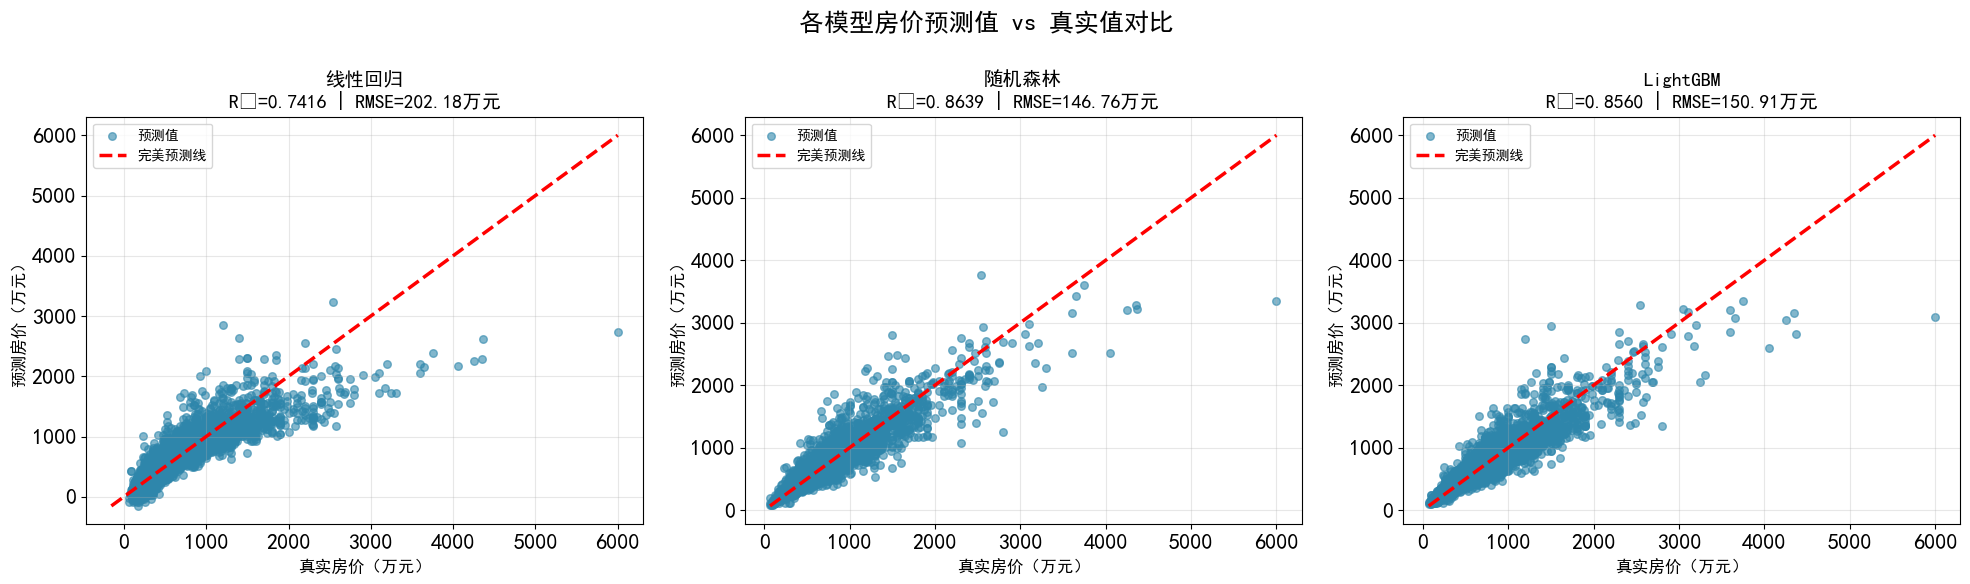

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import lightgbm as lgb

# ========== 解决Matplotlib中文显示问题 ==========
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

# 模型定义
models = {
    '线性回归': LinearRegression(),
    '随机森林': RandomForestRegressor(n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
}

# 训练并评估每个模型
results = {}
print("="*80)
print("多模型房价预测效果评估")
print("="*80)

# ========== 初始化绘图布局 ==========
# 创建3个子图（1行3列），画布大小适配3个模型
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# 设置总标题
fig.suptitle('各模型房价预测值 vs 真实值对比', fontsize=18, fontweight='bold')

# 遍历模型训练+绘图
for idx, (name, model) in enumerate(models.items()):
    # 构建完整管道（预处理+模型）
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # 训练模型
    pipeline.fit(X_train, y_train)
    
    # 预测
    y_pred = pipeline.predict(X_test)
    
    # 计算评估指标
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # 保存结果（新增y_pred用于绘图）
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': pipeline,
        'y_pred': y_pred  # 保存预测值
    }
    
    # 输出文本结果
    print(f"\n【{name}】")
    print(f"平均绝对误差(MAE)：{mae:.2f} 万元")
    print(f"均方根误差(RMSE)：{rmse:.2f} 万元")
    print(f"决定系数(R²)：{r2:.4f}")

    # ========== 绘制单个模型的预测值vs真实值图 ==========
    ax = axes[idx]  # 获取当前子图
    
    # 1. 绘制散点图：真实值为x轴，预测值为y轴
    # alpha=0.6 避免点重叠，s=30 调整点大小
    ax.scatter(y_test, y_pred, alpha=0.6, s=30, color='#2E86AB', label='预测值')
    
    # 2. 绘制完美预测线（y=x）：红色虚线，代表预测完全准确
    min_val = min(np.min(y_test), np.min(y_pred))  # 取真实/预测值最小值
    max_val = max(np.max(y_test), np.max(y_pred))  # 取真实/预测值最大值
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5, label='完美预测线')
    
    # 3. 设置子图样式
    ax.set_title(f'{name}\nR²={r2:.4f} | RMSE={rmse:.2f}万元', fontsize=14)
    ax.set_xlabel('真实房价（万元）', fontsize=12)
    ax.set_ylabel('预测房价（万元）', fontsize=12)
    ax.grid(True, alpha=0.3)  # 添加网格，增强可读性
    ax.legend(fontsize=10)

# ========== 调整布局并保存/显示图片 ==========
plt.tight_layout()  # 自动调整子图间距，避免文字重叠
plt.show()  # 显示图片

### 模型效果对比 （朱逸晗）

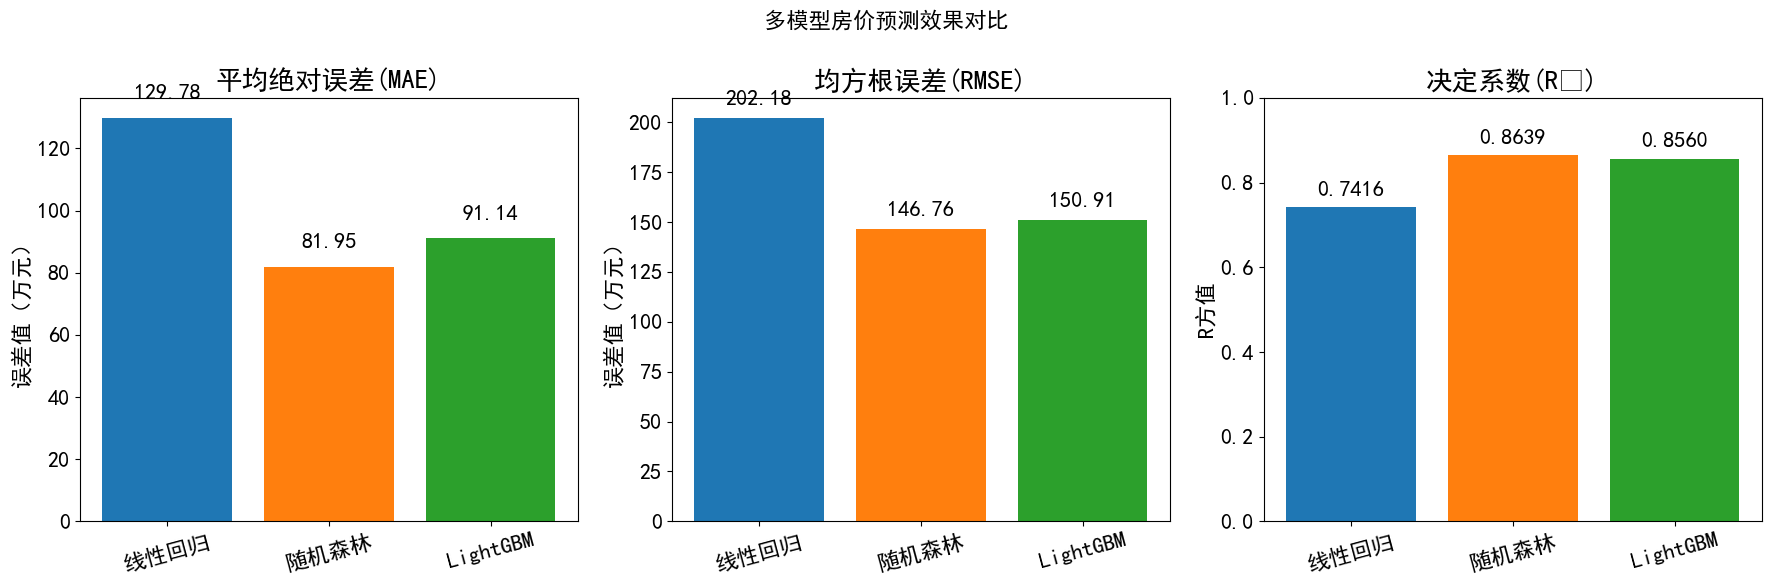

In [142]:
# 4.1 各模型评估指标对比
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('多模型房价预测效果对比', fontsize=16, fontweight='bold')

# 提取指标
model_names = list(results.keys())
mae_vals = [results[name]['MAE'] for name in model_names]
rmse_vals = [results[name]['RMSE'] for name in model_names]
r2_vals = [results[name]['R²'] for name in model_names]

# MAE对比
axes[0].bar(model_names, mae_vals, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('平均绝对误差(MAE)')
axes[0].set_ylabel('误差值（万元）')
axes[0].tick_params(axis='x', rotation=15)
# 添加数值标签
for i, v in enumerate(mae_vals):
    axes[0].text(i, v+5, f'{v:.2f}', ha='center', va='bottom')

# RMSE对比
axes[1].bar(model_names, rmse_vals, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_title('均方根误差(RMSE)')
axes[1].set_ylabel('误差值（万元）')
axes[1].tick_params(axis='x', rotation=15)
# 添加数值标签
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v+5, f'{v:.2f}', ha='center', va='bottom')

# R²对比
axes[2].bar(model_names, r2_vals, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[2].set_title('决定系数(R²)')
axes[2].set_ylabel('R方值')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=15)
# 添加数值标签
for i, v in enumerate(r2_vals):
    axes[2].text(i, v+0.02, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


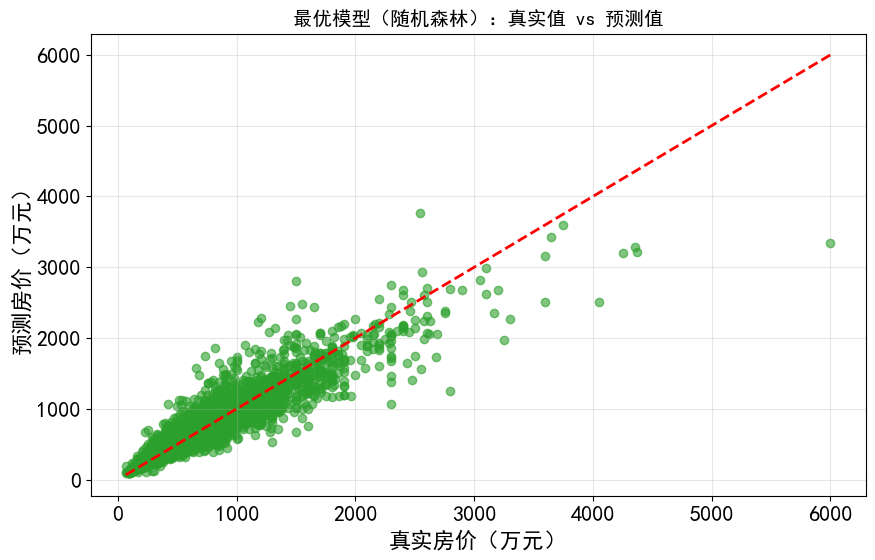

In [143]:
best_model_name = max(results.keys(), key=lambda x: results[x]['R²'])
best_model = results[best_model_name]['model']
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='#2ca02c')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('真实房价（万元）')
plt.ylabel('预测房价（万元）')
plt.title(f'最优模型（{best_model_name}）：真实值 vs 预测值', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [144]:
# 你原有的最优模型选择代码
best_model_name = max(results.keys(), key=lambda x: results[x]['R²'])
best_model = results[best_model_name]['model']
y_pred_best = best_model.predict(X_test)

# ========== 保存真实值和预测值到CSV ==========
df_result = pd.DataFrame({
    '真实房价_万元': y_test.values if hasattr(y_test, 'values') else y_test,
    '预测房价_万元': y_pred_best,
    '误差_万元': y_pred_best - (y_test.values if hasattr(y_test, 'values') else y_test),  # 新增误差列便于分析
    '绝对误差_万元': np.abs(y_pred_best - (y_test.values if hasattr(y_test, 'values') else y_test))
})

# 保存到CSV文件
csv_path = f'最优模型_{best_model_name}_房价预测结果.csv'
df_result.to_csv(csv_path, index=False, encoding='utf-8-sig')  # utf-8-sig解决中文乱码
print(f" 最优模型预测结果已保存至：{csv_path}")
print(f"\n 数据预览（前5行）：")
print(df_result.head())

 最优模型预测结果已保存至：最优模型_随机森林_房价预测结果.csv

 数据预览（前5行）：
   真实房价_万元     预测房价_万元      误差_万元    绝对误差_万元
0    505.0  421.890000 -83.110000  83.110000
1    320.0  354.350000  34.350000  34.350000
2    305.0  304.401167  -0.598833   0.598833
3    370.0  387.345000  17.345000  17.345000
4    520.0  518.660000  -1.340000   1.340000


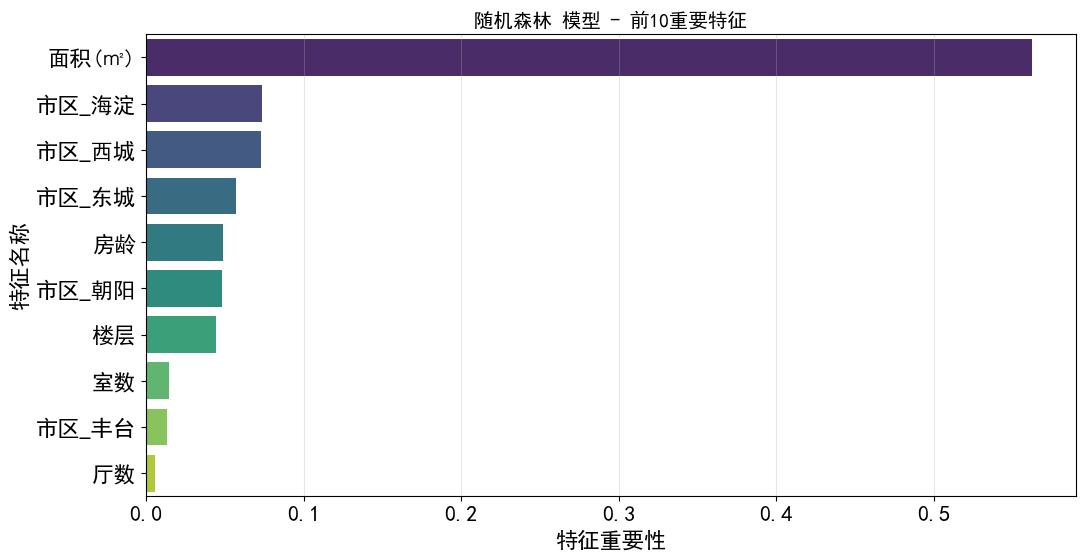


最终结论
1. 最优模型：随机森林（R²=0.8639）
2. 最差模型：线性回归（R²=0.7416）
3. 核心影响特征：面积(㎡)（重要性=0.56）
4. 模型平均预测误差：81.95 万元


In [145]:
cat_features_names = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_features_names = np.concatenate([numeric_features, cat_features_names])

# 修复：分模型正确提取特征重要性
if best_model_name == '线性回归':
    # 线性回归：用系数绝对值表示重要性
    importance = np.abs(best_model.named_steps['model'].coef_)
elif best_model_name in ['随机森林', 'LightGBM']:
    # 树模型：用feature_importances_表示重要性
    importance = best_model.named_steps['model'].feature_importances_
else:
    # 兜底：默认用0填充（实际不会走到这里）
    importance = np.zeros(len(all_features_names))

# 构建特征重要性DataFrame
importance_df = pd.DataFrame({
    '特征名称': all_features_names,
    '重要性': importance
}).sort_values('重要性', ascending=False).head(10)

# 可视化特征重要性
plt.figure(figsize=(12, 6))
sns.barplot(x='重要性', y='特征名称', data=importance_df, palette='viridis')
plt.title(f'{best_model_name} 模型 - 前10重要特征', fontsize=14)
plt.xlabel('特征重要性')
plt.ylabel('特征名称')
plt.grid(True, alpha=0.3, axis='x')
plt.show()

# 输出最终结论
print("\n" + "="*80)
print("最终结论")
print("="*80)
print(f"1. 最优模型：{best_model_name}（R²={results[best_model_name]['R²']:.4f}）")
print(f"2. 最差模型：{min(results.keys(), key=lambda x: results[x]['R²'])}（R²={results[min(results.keys(), key=lambda x: results[x]['R²'])]['R²']:.4f}）")
print(f"3. 核心影响特征：{importance_df.iloc[0]['特征名称']}（重要性={importance_df.iloc[0]['重要性']:.2f}）")
print(f"4. 模型平均预测误差：{results[best_model_name]['MAE']:.2f} 万元")